# 🛒 Tokopedia — End-to-End NLP Pipeline
## E-Commerce Customer Sentiment & Feedback Analysis for Product Quality Improvement
---

### 📋 Alur Pipeline:

| Tahap | Section | Deskripsi |
|-------|---------|-----------|
| **I. Data Preparation** | 1–4 | Install, Import, Load Data, Data Cleaning |
| **II. Exploratory Data Analysis** | 5–9 | Sentimen, Kategori, Harga, Tren, Scorecard |
| **III. Modeling** | 10–18 | Labeling, Preprocessing, Baseline ML, LSTM, BiLSTM, CNN, IndoBERT, Tuning, Evaluasi |

> **Dataset:** Tokopedia Product Reviews 2025 · 65.543 review · 6 kategori  
> **Task 1:** Sentimen → `positif` / `netral` / `negatif`  
> **Task 2:** Kategori Review → `produk` / `pengiriman` / `produk_dan_pengiriman` / `umum`

---
# 📦 Bagian I — Data Preparation

## 1. Install & Import Library

In [ ]:
# Jalankan sekali untuk install dependencies
%pip install -q tensorflow "transformers<5.0" scikit-learn imbalanced-learn keras-tuner matplotlib seaborn pandas numpy Sastrawi gensim
print("Lanjutkan ke cell berikutnya setelah instalasi selesai.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.20.1
    Uninstalling huggingface_hub-1.20.1:
      Successfully uninstalled huggingface_hub-1.20.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
Lanjutkan ke cell beriku

In [ ]:
!pip uninstall -y jax jaxlib tensorstore tensorflow-text ydf-tf -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#EEEEEE',
    'grid.linewidth': 0.6,
    'font.size': 10,
})

TEAL  = '#1D9E75'
AMBER = '#EF9F27'
RED   = '#E24B4A'
BLUE  = '#378ADD'
LTEAL = '#5DCAA5'
GRAY  = '#888780'

print('Library berhasil diimport.')

Library berhasil diimport.


In [ ]:
# ── Library Deep Learning & NLP (tambahan) ───────────────────────────
import warnings, re, unicodedata
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

try:
    import keras_tuner as kt; HAS_KT = True
except: HAS_KT = False; print("keras-tuner tidak tersedia.")

try:
    from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
    HAS_BERT = True
except: HAS_BERT = False; print("transformers tidak tersedia.")

SEED = 42
import numpy as np; import tensorflow as tf
np.random.seed(SEED); tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU aktif  : {len(tf.config.list_physical_devices('GPU')) > 0}")
print("Semua library siap ✅")

TensorFlow : 2.20.0
GPU aktif  : True
Semua library siap ✅


## 2. Load Data

In [ ]:
df_raw = pd.read_csv('tokopedia_product_reviews_2025.csv')

print(f'Shape      : {df_raw.shape}')
print(f'Kolom      : {df_raw.columns.tolist()}')
print()
df_raw.head()

FileNotFoundError: [Errno 2] No such file or directory: 'tokopedia_product_reviews_2025.csv'

In [ ]:
df_raw.dtypes

,0
review_text,object
review_date,object
review_id,int64
product_name,object
product_category,object
product_variant,object
product_price,int64
product_url,object
product_id,int64
rating,int64


In [ ]:
df_raw.describe(include='all')

,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
count,65543,65543,6.554300e+04,65543,65543,26749,6.554300e+04,65543,6.554300e+04,65543.000000,65543.000000,6.554300e+04,65543
unique,58068,2845,NaN,5418,6,5511,NaN,5521,NaN,NaN,NaN,NaN,3
top,Bagus,2025-10-15,NaN,Chosamon Mid Top Original Sepatu Sneakers Olah...,Makanan & Minuman,Default,NaN,https://www.tokopedia.com/sasaofficial/sasa-te...,NaN,NaN,NaN,NaN,positive
freq,323,83,NaN,80,17859,1733,NaN,20,NaN,NaN,NaN,NaN,63943
mean,NaN,NaN,9.814143e+08,NaN,NaN,NaN,5.421295e+05,NaN,2.447482e+10,4.893764,1954.923897,7.615674e+16,NaN
std,NaN,NaN,4.193324e+08,NaN,NaN,NaN,2.365557e+06,NaN,3.870717e+10,0.492495,18244.026827,7.516573e+17,NaN
min,NaN,NaN,1.027202e+07,NaN,NaN,NaN,1.000000e+02,NaN,4.298375e+06,1.000000,6.000000,6.050000e+02,NaN
25%,NaN,NaN,7.182240e+08,NaN,NaN,NaN,2.990000e+04,NaN,1.446882e+09,5.000000,100.000000,2.298522e+06,NaN
50%,NaN,NaN,9.740048e+08,NaN,NaN,NaN,8.000000e+04,NaN,4.769575e+09,5.000000,500.000000,5.801280e+06,NaN
75%,NaN,NaN,1.145967e+09,NaN,NaN,NaN,2.146870e+05,NaN,1.534605e+10,5.000000,1000.000000,9.061811e+06,NaN


## 3. Data Cleaning
### 3.1 Eksplorasi Awal — Sebelum Cleaning

In [ ]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

quality_before = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct,
    'Status': ['MISSING ⚠️' if v > 0 else 'OK ✅' for v in missing]
})

print(f'Total duplikat : {df_raw.duplicated().sum()}')
print()
quality_before

Total duplikat : 0



,Missing Count,Missing (%),Status
review_text,0,0.00,OK ✅
review_date,0,0.00,OK ✅
review_id,0,0.00,OK ✅
product_name,0,0.00,OK ✅
product_category,0,0.00,OK ✅
product_variant,38794,59.19,MISSING ⚠️
product_price,0,0.00,OK ✅
product_url,0,0.00,OK ✅
product_id,0,0.00,OK ✅
rating,0,0.00,OK ✅


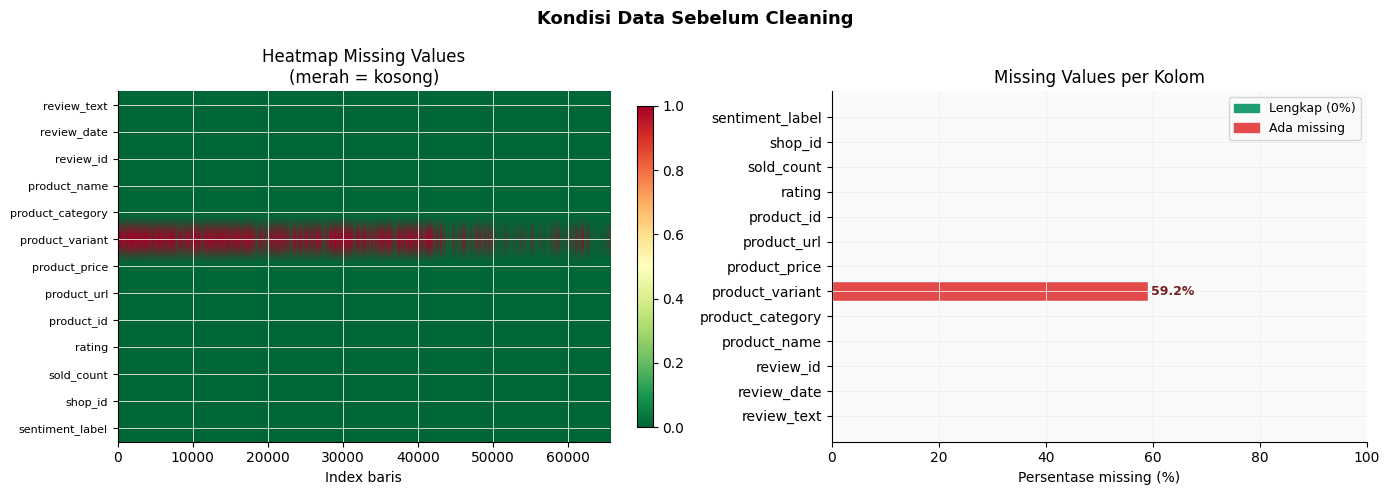

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kondisi Data Sebelum Cleaning', fontsize=13, fontweight='bold')

# Heatmap missing values
ax = axes[0]
im = ax.imshow(df_raw.isnull().astype(int).T, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_yticks(range(len(df_raw.columns)))
ax.set_yticklabels(df_raw.columns, fontsize=8)
ax.set_xlabel('Index baris')
ax.set_title('Heatmap Missing Values\n(merah = kosong)')
plt.colorbar(im, ax=ax, fraction=0.03)

# Bar chart missing per kolom
ax = axes[1]
colors = [RED if v > 0 else TEAL for v in missing_pct]
bars = ax.barh(df_raw.columns, missing_pct, color=colors, edgecolor='white')
ax.set_xlabel('Persentase missing (%)')
ax.set_title('Missing Values per Kolom')
ax.set_xlim(0, 100)
for bar, pct in zip(bars, missing_pct):
    if pct > 0:
        ax.text(pct + 0.5, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=9, color='#791F1F', fontweight='bold')

patch_ok = mpatches.Patch(color=TEAL, label='Lengkap (0%)')
patch_mv = mpatches.Patch(color=RED,  label='Ada missing')
axes[1].legend(handles=[patch_ok, patch_mv], fontsize=9)
plt.tight_layout()
plt.show()

### 3.2 Proses Cleaning

In [ ]:
# ── Proses Cleaning ──────────────────────────────────────────────────
df = df_raw.copy()

# Step 1: Isi missing product_variant
before_mv = df['product_variant'].isnull().sum()
df['product_variant'] = df['product_variant'].fillna('Tidak ada varian')
print(f"[product_variant] Missing: {before_mv:,} → {df['product_variant'].isnull().sum()} ✅")

# Step 2: Hapus duplikat
before_dup = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"[duplikat]        Dihapus: {before_dup} baris ✅")

# Step 3: Konversi tipe data
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')
print(f"[review_date]     Dikonversi ke datetime ✅")

# Step 4: Feature engineering
df['year']      = df['review_date'].dt.year
df['month']     = df['review_date'].dt.month
df['yearmonth'] = df['review_date'].dt.to_period('M')

print(f"\nShape sebelum : {df_raw.shape}")
print(f"Shape sesudah  : {df.shape}")
print(f"\nKategori produk ({df['product_category'].nunique()}):")
print(df['product_category'].value_counts())
print("\nCleaning selesai ✅")


[product_variant] Missing: 38,794 → 0 ✅
[duplikat]        Dihapus: 0 baris ✅
[review_date]     Dikonversi ke datetime ✅

Shape sebelum : (65543, 13)
Shape sesudah  : (65543, 16)

Kategori produk (6):
product_category
Makanan & Minuman     17859
Olahraga              15600
Pertukangan           11500
Kesehatan              8959
Handphone & Tablet     7423
Elektronik             4202
Name: count, dtype: int64

Cleaning selesai ✅


### 3.3 Validasi Hasil Cleaning

In [ ]:
missing2 = df.isnull().sum()
quality_after = pd.DataFrame({
    'Missing Count': missing2,
    'Missing (%)': (missing2 / len(df) * 100).round(2),
    'Status': ['MISSING ⚠️' if v > 0 else 'OK ✅' for v in missing2]
})
print(f'Total duplikat sesudah cleaning: {df.duplicated().sum()}')
print()
quality_after

Total duplikat sesudah cleaning: 0



,Missing Count,Missing (%),Status
review_text,0,0.0,OK ✅
review_date,0,0.0,OK ✅
review_id,0,0.0,OK ✅
product_name,0,0.0,OK ✅
product_category,0,0.0,OK ✅
product_variant,0,0.0,OK ✅
product_price,0,0.0,OK ✅
product_url,0,0.0,OK ✅
product_id,0,0.0,OK ✅
rating,0,0.0,OK ✅


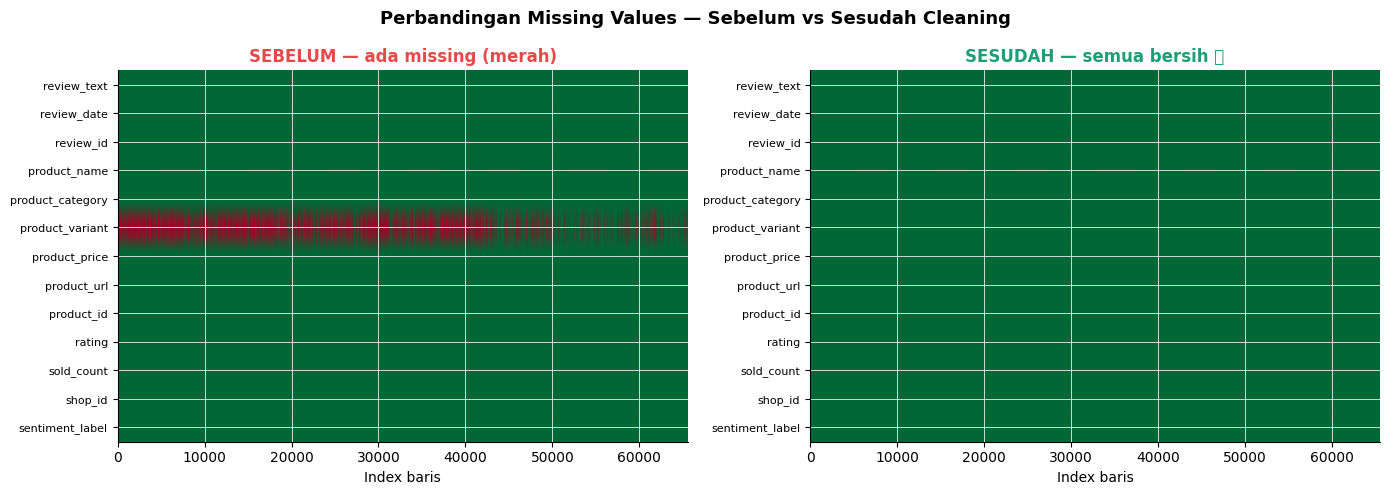

File cleaned disimpan: tokopedia_cleaned.csv ✅
Shape df final: (65543, 16)
Jumlah kategori: 6
Kategori: ['Makanan & Minuman', 'Kesehatan', 'Elektronik', 'Pertukangan', 'Handphone & Tablet', 'Olahraga']


In [ ]:
# ── Visualisasi perbandingan sebelum vs sesudah cleaning ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Missing Values — Sebelum vs Sesudah Cleaning',
             fontsize=13, fontweight='bold')

# Sebelum
ax = axes[0]
im1 = ax.imshow(df_raw.isnull().astype(int).T, aspect='auto',
                cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_yticks(range(len(df_raw.columns)))
ax.set_yticklabels(df_raw.columns, fontsize=8)
ax.set_title('SEBELUM — ada missing (merah)', color=RED, fontweight='bold')
ax.set_xlabel('Index baris')

# Sesudah — pakai kolom yang sama dengan df_raw saja untuk heatmap
ax = axes[1]
im2 = ax.imshow(df[df_raw.columns].isnull().astype(int).T, aspect='auto',
                cmap='RdYlGn_r', vmin=0, vmax=1)
ax.set_yticks(range(len(df_raw.columns)))
ax.set_yticklabels(df_raw.columns, fontsize=8)
ax.set_title('SESUDAH — semua bersih ✅', color=TEAL, fontweight='bold')
ax.set_xlabel('Index baris')

plt.tight_layout()
plt.show()

# ── SIMPAN FILE CLEANED ────────────────────────────────────────────────
df.to_csv('tokopedia_cleaned.csv', index=False)
print(f"File cleaned disimpan: tokopedia_cleaned.csv ✅")
print(f"Shape df final: {df.shape}")
print(f"Jumlah kategori: {df['product_category'].nunique()}")
print(f"Kategori: {df['product_category'].unique().tolist()}")


## 4. Feature Engineering

In [ ]:
# ── Feature Engineering untuk EDA ───────────────────────────────────
df['review_len']  = df['review_text'].str.len()
df['has_variant'] = df['product_variant'] != 'Tidak ada varian'
df['price_range'] = pd.cut(
    df['product_price'],
    bins=[0, 50_000, 200_000, 500_000, 1_000_000, float('inf')],
    labels=['<50rb','50-200rb','200-500rb','500rb-1jt','>1jt']
)

# ── VALIDASI WAJIB sebelum lanjut ke EDA ──────────────────────────────
print("=" * 50)
print("  VALIDASI DATA SEBELUM EDA")
print("=" * 50)
print(f"  Total baris        : {len(df):,}")
print(f"  Total kolom        : {len(df.columns)}")
print(f"  Jumlah kategori    : {df['product_category'].nunique()}")
print(f"  Missing values     : {df.isnull().sum().sum()}")
print(f"  Duplikat           : {df.duplicated().sum()}")
print()
print("  Distribusi kategori:")
for cat, cnt in df['product_category'].value_counts().items():
    print(f"    {cat:<25s}: {cnt:>6,} review")
print()

# Cek wajib — stop jika data tidak lengkap
assert df['product_category'].nunique() == 6, \
    f"❌ Kategori tidak lengkap! Hanya {df['product_category'].nunique()} kategori. Restart & Run All!"
assert len(df) > 60_000, \
    f"❌ Data tidak lengkap! Hanya {len(df):,} baris. Restart & Run All!"

print("✅ Semua validasi lolos — siap lanjut ke EDA!")


  VALIDASI DATA SEBELUM EDA
  Total baris        : 65,543
  Total kolom        : 19
  Jumlah kategori    : 6
  Missing values     : 0
  Duplikat           : 0

  Distribusi kategori:
    Makanan & Minuman        : 17,859 review
    Olahraga                 : 15,600 review
    Pertukangan              : 11,500 review
    Kesehatan                :  8,959 review
    Handphone & Tablet       :  7,423 review
    Elektronik               :  4,202 review

✅ Semua validasi lolos — siap lanjut ke EDA!


---
# 🔍 Bagian II — Exploratory Data Analysis (EDA)

## 5. EDA — Sentimen & Rating

In [ ]:
sent_counts = df['sentiment_label'].value_counts()
rating_counts = df['rating'].value_counts().sort_index()

print('=== DISTRIBUSI SENTIMEN ===')
for s, v in sent_counts.items():
    print(f'  {s:10s}: {v:>6,}  ({v/len(df)*100:.2f}%)')

print('\n=== DISTRIBUSI RATING ===')
for r, v in rating_counts.items():
    print(f'  Bintang {r}: {v:>6,}  ({v/len(df)*100:.2f}%)')

print('\n=== PANJANG REVIEW PER SENTIMEN ===')
print(df.groupby('sentiment_label')['review_len'].agg(['mean','median']).round(1))

=== DISTRIBUSI SENTIMEN ===
  positive  : 63,943  (97.56%)
  neutral   :    802  (1.22%)
  negative  :    798  (1.22%)

=== DISTRIBUSI RATING ===
  Bintang 1:    547  (0.83%)
  Bintang 2:    251  (0.38%)
  Bintang 3:    802  (1.22%)
  Bintang 4:  2,418  (3.69%)
  Bintang 5: 61,525  (93.87%)

=== PANJANG REVIEW PER SENTIMEN ===
                  mean  median
sentiment_label               
negative         144.0    90.0
neutral          110.5    78.0
positive          77.3    59.0


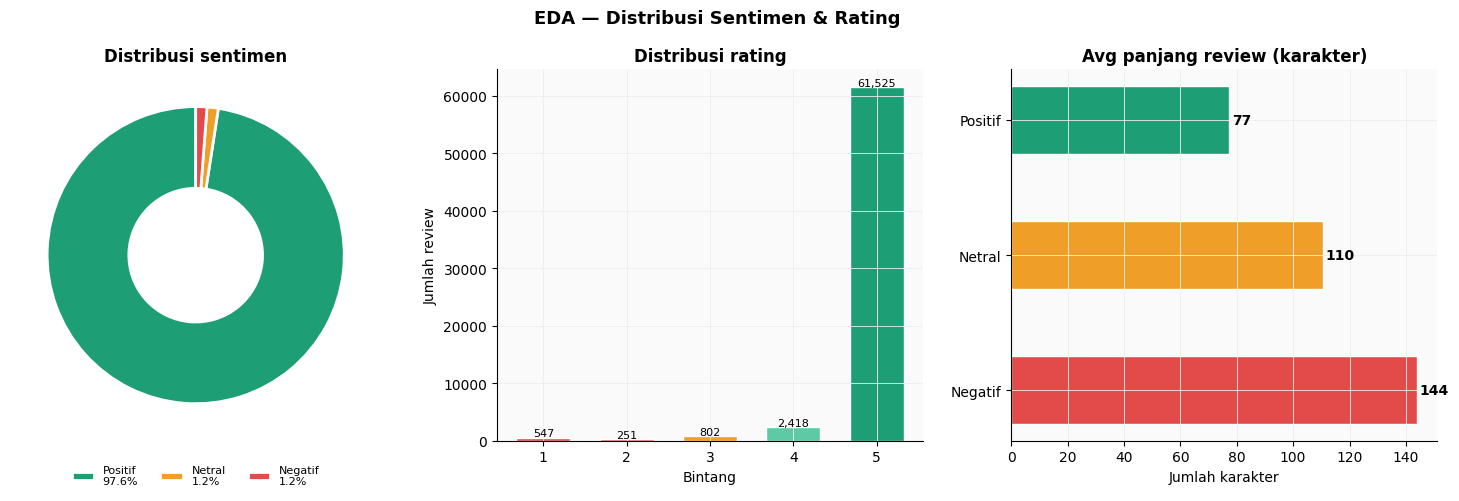

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('EDA — Distribusi Sentimen & Rating', fontsize=13, fontweight='bold')

# Donut sentimen
ax = axes[0]
sizes  = [sent_counts.get('positive',0), sent_counts.get('neutral',0), sent_counts.get('negative',0)]
clrs   = [TEAL, AMBER, RED]
lbls   = [f"Positif\n{sizes[0]/len(df)*100:.1f}%",
           f"Netral\n{sizes[1]/len(df)*100:.1f}%",
           f"Negatif\n{sizes[2]/len(df)*100:.1f}%"]
w, t = ax.pie(sizes, colors=clrs, startangle=90, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
ax.set_title('Distribusi sentimen', fontweight='bold')
ax.legend(w, lbls, loc='lower center', fontsize=8, frameon=False, bbox_to_anchor=(0.5,-0.15), ncol=3)

# Bar rating
ax = axes[1]
bar_c = [RED, RED, AMBER, LTEAL, TEAL]
bars = ax.bar(rating_counts.index, rating_counts.values, color=bar_c, edgecolor='white', width=0.65)
ax.set_title('Distribusi rating', fontweight='bold')
ax.set_xlabel('Bintang'); ax.set_ylabel('Jumlah review')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+200, f'{h:,}', ha='center', fontsize=8)

# Panjang review per sentimen
ax = axes[2]
rev_len = df.groupby('sentiment_label')['review_len'].mean().reindex(['negative','neutral','positive'])
ax.barh(['Negatif','Netral','Positif'], rev_len.values,
        color=[RED, AMBER, TEAL], edgecolor='white', height=0.5)
ax.set_title('Avg panjang review (karakter)', fontweight='bold')
ax.set_xlabel('Jumlah karakter')
for i, v in enumerate(rev_len.values):
    ax.text(v+1, i, f'{v:.0f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. EDA — Analisis per Kategori

In [ ]:
cat_stats = df.groupby('product_category').agg(
    total_review  = ('review_id',       'count'),
    avg_rating    = ('rating',          'mean'),
    pos_rate_pct  = ('sentiment_label', lambda x: (x=='positive').mean()*100),
    neg_rate_pct  = ('sentiment_label', lambda x: (x=='negative').mean()*100),
    avg_price     = ('product_price',   'mean'),
    median_sold   = ('sold_count',      'median'),
    avg_rev_len   = ('review_len',      'mean'),
).round(2)
cat_stats['quality_score'] = (cat_stats['avg_rating'] * cat_stats['pos_rate_pct'] / 100 * 20).round(1)
cat_stats.sort_values('quality_score', ascending=False)

,total_review,avg_rating,pos_rate_pct,neg_rate_pct,avg_price,median_sold,avg_rev_len,quality_score
product_category,,,,,,,,
Elektronik,4202,4.95,98.93,0.57,3491540.60,100.0,75.44,97.9
Kesehatan,8959,4.94,98.85,0.44,133629.43,500.0,77.07,97.7
Handphone & Tablet,7423,4.93,98.49,0.84,1340293.52,100.0,81.14,97.1
Pertukangan,11500,4.89,97.57,1.16,277986.81,500.0,66.88,95.4
Makanan & Minuman,17859,4.88,96.90,1.47,79122.57,1000.0,88.27,94.6
Olahraga,15600,4.85,96.76,1.78,327260.20,250.0,76.53,93.9


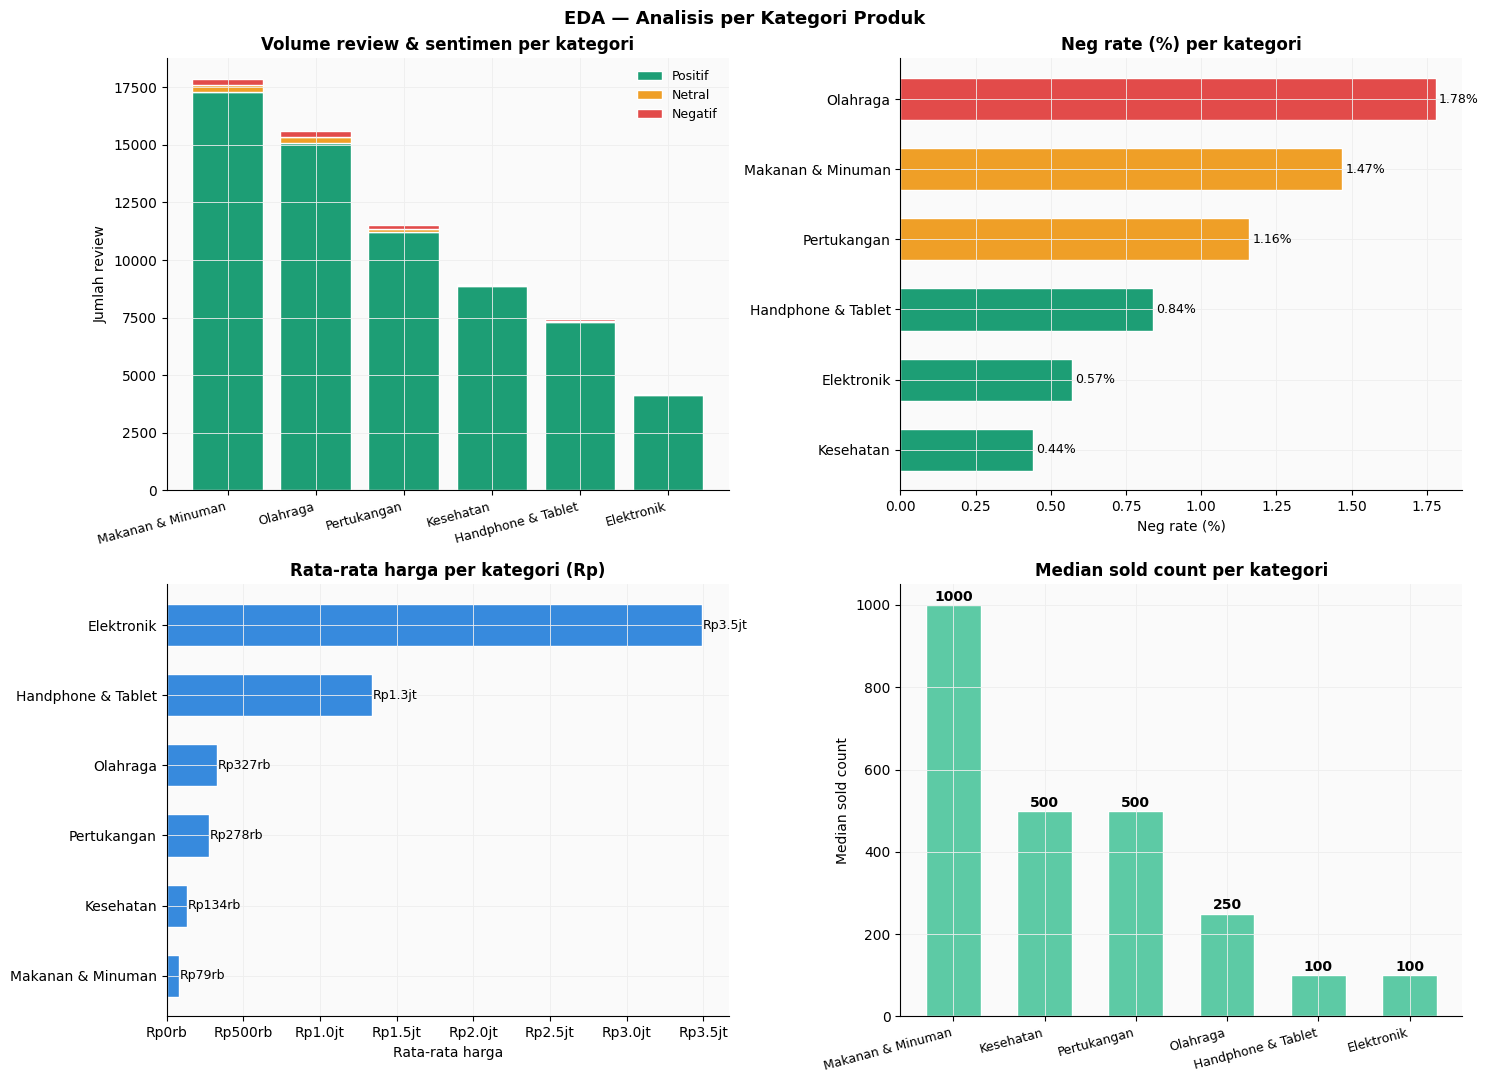

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('EDA — Analisis per Kategori Produk', fontsize=13, fontweight='bold')

cats = cat_stats.sort_values('total_review', ascending=False).index.tolist()

# Stacked bar sentimen
ax = axes[0, 0]
pos_v = [df[(df['product_category']==c)&(df['sentiment_label']=='positive')].shape[0] for c in cats]
neu_v = [df[(df['product_category']==c)&(df['sentiment_label']=='neutral')].shape[0]  for c in cats]
neg_v = [df[(df['product_category']==c)&(df['sentiment_label']=='negative')].shape[0] for c in cats]
x = np.arange(len(cats))
ax.bar(x, pos_v, label='Positif', color=TEAL, edgecolor='white')
ax.bar(x, neu_v, bottom=pos_v, label='Netral', color=AMBER, edgecolor='white')
ax.bar(x, neg_v, bottom=[p+n for p,n in zip(pos_v,neu_v)], label='Negatif', color=RED, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(cats, rotation=15, ha='right', fontsize=9)
ax.set_title('Volume review & sentimen per kategori', fontweight='bold')
ax.set_ylabel('Jumlah review'); ax.legend(fontsize=9, frameon=False)

# Neg rate per kategori
ax = axes[0, 1]
neg_rates = cat_stats['neg_rate_pct'].sort_values()
clr_nr = [RED if v > 1.5 else (AMBER if v > 1.0 else TEAL) for v in neg_rates]
ax.barh(neg_rates.index, neg_rates.values, color=clr_nr, edgecolor='white', height=0.6)
ax.set_title('Neg rate (%) per kategori', fontweight='bold')
ax.set_xlabel('Neg rate (%)')
for i, v in enumerate(neg_rates.values):
    ax.text(v+0.01, i, f'{v:.2f}%', va='center', fontsize=9)

# Avg harga per kategori
ax = axes[1, 0]
avg_price = cat_stats['avg_price'].sort_values()
ax.barh(avg_price.index, avg_price.values, color=BLUE, edgecolor='white', height=0.6)
ax.set_title('Rata-rata harga per kategori (Rp)', fontweight='bold')
ax.set_xlabel('Rata-rata harga')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'Rp{v/1e6:.1f}jt' if v>=1e6 else f'Rp{v/1e3:.0f}rb'))
for i, v in enumerate(avg_price.values):
    label = f'Rp{v/1e6:.1f}jt' if v>=1e6 else f'Rp{v/1e3:.0f}rb'
    ax.text(v+5000, i, label, va='center', fontsize=9)

# Median sold count per kategori
ax = axes[1, 1]
med_sold = cat_stats['median_sold'].sort_values(ascending=False)
ax.bar(med_sold.index, med_sold.values, color=LTEAL, edgecolor='white', width=0.6)
ax.set_xticklabels(med_sold.index, rotation=15, ha='right', fontsize=9)
ax.set_title('Median sold count per kategori', fontweight='bold')
ax.set_ylabel('Median sold count')
for i, (cat, v) in enumerate(med_sold.items()):
    ax.text(i, v+10, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. EDA — Harga vs Kualitas

In [ ]:
price_sent = df.groupby('price_range', observed=True).agg(
    count      = ('review_id',       'count'),
    neg_rate   = ('sentiment_label', lambda x: (x=='negative').mean()*100),
    pos_rate   = ('sentiment_label', lambda x: (x=='positive').mean()*100),
    avg_rating = ('rating',          'mean'),
).round(2)
print('=== SENTIMEN & RATING PER RENTANG HARGA ===')
price_sent

=== SENTIMEN & RATING PER RENTANG HARGA ===


,count,neg_rate,pos_rate,avg_rating
price_range,,,,
<50rb,24606,1.32,97.23,4.88
50-200rb,23741,1.47,97.20,4.88
200-500rb,8908,0.89,98.20,4.91
500rb-1jt,2968,0.74,98.35,4.92
>1jt,5320,0.41,99.15,4.96


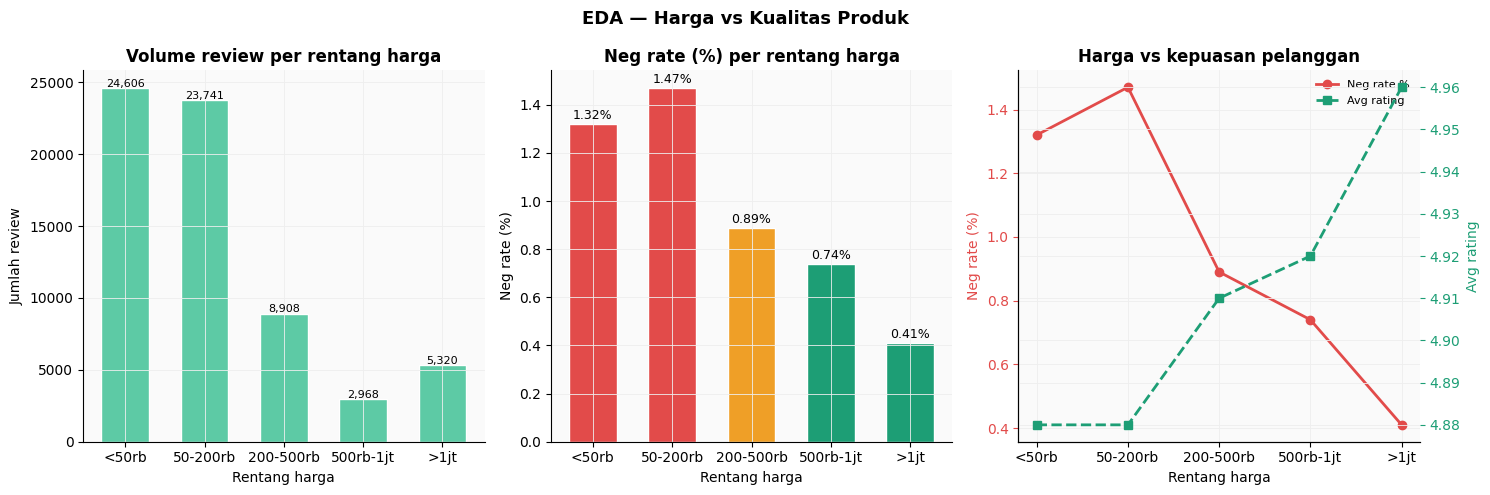

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('EDA — Harga vs Kualitas Produk', fontsize=13, fontweight='bold')

pr_labels = price_sent.index.astype(str).tolist()

# Distribusi volume per harga
ax = axes[0]
ax.bar(pr_labels, price_sent['count'], color=LTEAL, edgecolor='white', width=0.6)
ax.set_title('Volume review per rentang harga', fontweight='bold')
ax.set_xlabel('Rentang harga'); ax.set_ylabel('Jumlah review')
for i, v in enumerate(price_sent['count']):
    ax.text(i, v+100, f'{v:,}', ha='center', fontsize=8)

# Neg rate per harga
ax = axes[1]
clr_p = [RED if v > 1.2 else (AMBER if v > 0.8 else TEAL) for v in price_sent['neg_rate']]
bars = ax.bar(pr_labels, price_sent['neg_rate'], color=clr_p, edgecolor='white', width=0.6)
ax.set_title('Neg rate (%) per rentang harga', fontweight='bold')
ax.set_xlabel('Rentang harga'); ax.set_ylabel('Neg rate (%)')
for bar, v in zip(bars, price_sent['neg_rate']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.2f}%', ha='center', fontsize=9)

# Dual axis neg rate + avg rating
ax = axes[2]
ax2 = ax.twinx()
ax.plot(pr_labels, price_sent['neg_rate'],   color=RED,  marker='o', linewidth=2, label='Neg rate %')
ax2.plot(pr_labels, price_sent['avg_rating'], color=TEAL, marker='s', linewidth=2,
         linestyle='--', label='Avg rating')
ax.set_title('Harga vs kepuasan pelanggan', fontweight='bold')
ax.set_ylabel('Neg rate (%)', color=RED); ax2.set_ylabel('Avg rating', color=TEAL)
ax.tick_params(axis='y', colors=RED); ax2.tick_params(axis='y', colors=TEAL)
l1,n1 = ax.get_legend_handles_labels(); l2,n2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, n1+n2, fontsize=8, frameon=False)
ax.set_xlabel('Rentang harga')

plt.tight_layout()
plt.show()

## 8. EDA — Tren Waktu

In [ ]:
yr_data = df[df['year'] >= 2020].groupby('year').size().reset_index(name='count')
yr_data['growth_pct'] = yr_data['count'].pct_change() * 100
print('=== PERTUMBUHAN REVIEW TAHUNAN ===')
print(yr_data.to_string(index=False))

=== PERTUMBUHAN REVIEW TAHUNAN ===
 year  count  growth_pct
 2020   2708         NaN
 2021   6499  139.992614
 2022  12326   89.659948
 2023  10874  -11.779977
 2024  16042   47.526209
 2025  15742   -1.870091


In [ ]:
recent = df[df['year'] >= 2024].copy()
monthly_neg = recent.groupby('yearmonth')['sentiment_label'].apply(
    lambda x: (x=='negative').mean()*100
).reset_index()
monthly_neg.columns = ['yearmonth', 'neg_rate']
monthly_neg['label'] = monthly_neg['yearmonth'].astype(str).str[2:]

monthly_vol = recent.groupby('yearmonth').size().reset_index(name='count')
print('=== TREN BULANAN 2024-2025 ===')
print(monthly_neg[['label','neg_rate']].to_string(index=False))

=== TREN BULANAN 2024-2025 ===
label  neg_rate
24-01  0.915565
24-02  0.745474
24-03  0.509771
24-04  1.766190
24-05  0.888231
24-06  0.775862
24-07  1.263823
24-08  0.382166
24-09  1.205546
24-10  0.759790
24-11  0.974026
24-12  1.603206
25-01  1.952807
25-02  1.372370
25-03  1.024765
25-04  1.701323
25-05  1.802508
25-06  1.810345
25-07  1.763804
25-08  1.309227
25-09  1.562500
25-10  1.498335
25-11  0.824499
25-12  1.903367


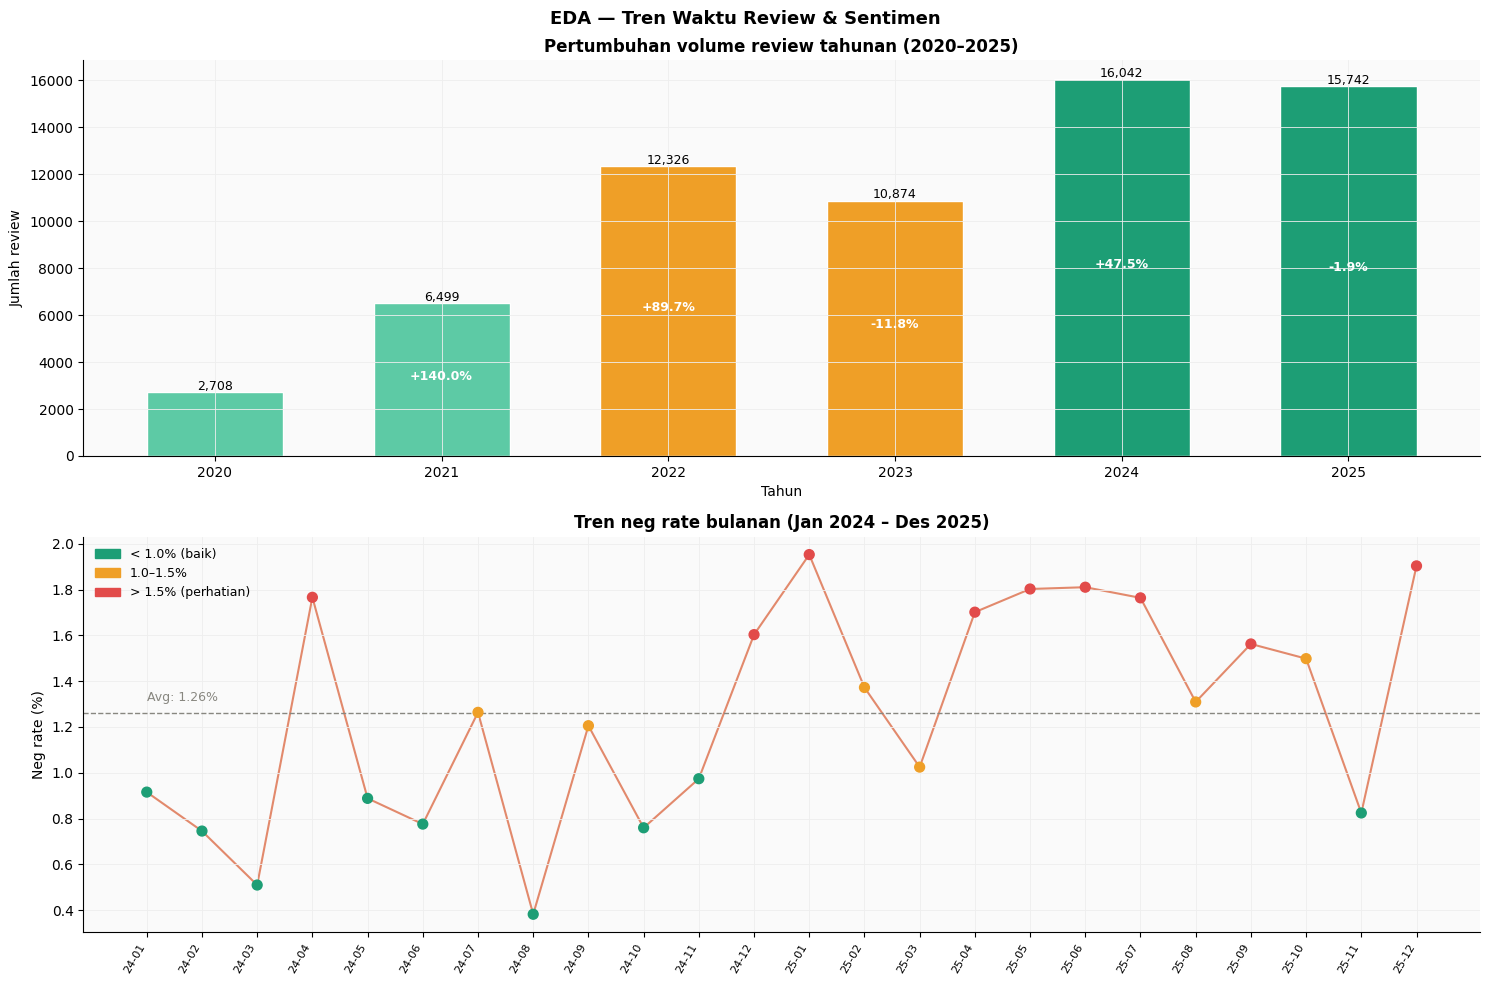

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('EDA — Tren Waktu Review & Sentimen', fontsize=13, fontweight='bold')

# Pertumbuhan tahunan
ax = axes[0]
yr_clr = [TEAL if v >= 14000 else (AMBER if v >= 10000 else LTEAL) for v in yr_data['count']]
bars = ax.bar(yr_data['year'], yr_data['count'], color=yr_clr, edgecolor='white', width=0.6)
ax.set_title('Pertumbuhan volume review tahunan (2020–2025)', fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Jumlah review')
for bar, row in zip(bars, yr_data.itertuples()):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+100, f'{h:,}', ha='center', fontsize=9)
    if not np.isnan(row.growth_pct):
        color = TEAL if row.growth_pct > 0 else RED
        ax.text(bar.get_x()+bar.get_width()/2, h/2,
                f'{row.growth_pct:+.1f}%', ha='center', fontsize=9, color='white', fontweight='bold')

# Tren neg rate bulanan
ax = axes[1]
pt_clr = [RED if v > 1.5 else (AMBER if v > 1.0 else TEAL) for v in monthly_neg['neg_rate']]
ax.plot(monthly_neg['label'], monthly_neg['neg_rate'],
        color='#D85A30', linewidth=1.5, alpha=0.7, zorder=1)
ax.scatter(monthly_neg['label'], monthly_neg['neg_rate'], c=pt_clr, zorder=5, s=50)
avg_nr = monthly_neg['neg_rate'].mean()
ax.axhline(avg_nr, color=GRAY, linestyle='--', linewidth=1)
ax.text(0, avg_nr+0.05, f'Avg: {avg_nr:.2f}%', fontsize=9, color=GRAY)
ax.set_xticks(range(len(monthly_neg)))
ax.set_xticklabels(monthly_neg['label'], rotation=60, ha='right', fontsize=8)
ax.set_title('Tren neg rate bulanan (Jan 2024 – Des 2025)', fontweight='bold')
ax.set_ylabel('Neg rate (%)')

p1 = mpatches.Patch(color=TEAL,  label='< 1.0% (baik)')
p2 = mpatches.Patch(color=AMBER, label='1.0–1.5%')
p3 = mpatches.Patch(color=RED,   label='> 1.5% (perhatian)')
ax.legend(handles=[p1,p2,p3], fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

## 9. Quality Scorecard & Rekomendasi Strategis

In [ ]:
print('=== QUALITY SCORECARD PER KATEGORI (skala 0-100) ===')
scorecard = cat_stats[['total_review','avg_rating','pos_rate_pct','neg_rate_pct','quality_score']]\
    .sort_values('quality_score', ascending=False)
scorecard

=== QUALITY SCORECARD PER KATEGORI (skala 0-100) ===


,total_review,avg_rating,pos_rate_pct,neg_rate_pct,quality_score
product_category,,,,,
Elektronik,4202,4.95,98.93,0.57,97.9
Kesehatan,8959,4.94,98.85,0.44,97.7
Handphone & Tablet,7423,4.93,98.49,0.84,97.1
Pertukangan,11500,4.89,97.57,1.16,95.4
Makanan & Minuman,17859,4.88,96.90,1.47,94.6
Olahraga,15600,4.85,96.76,1.78,93.9


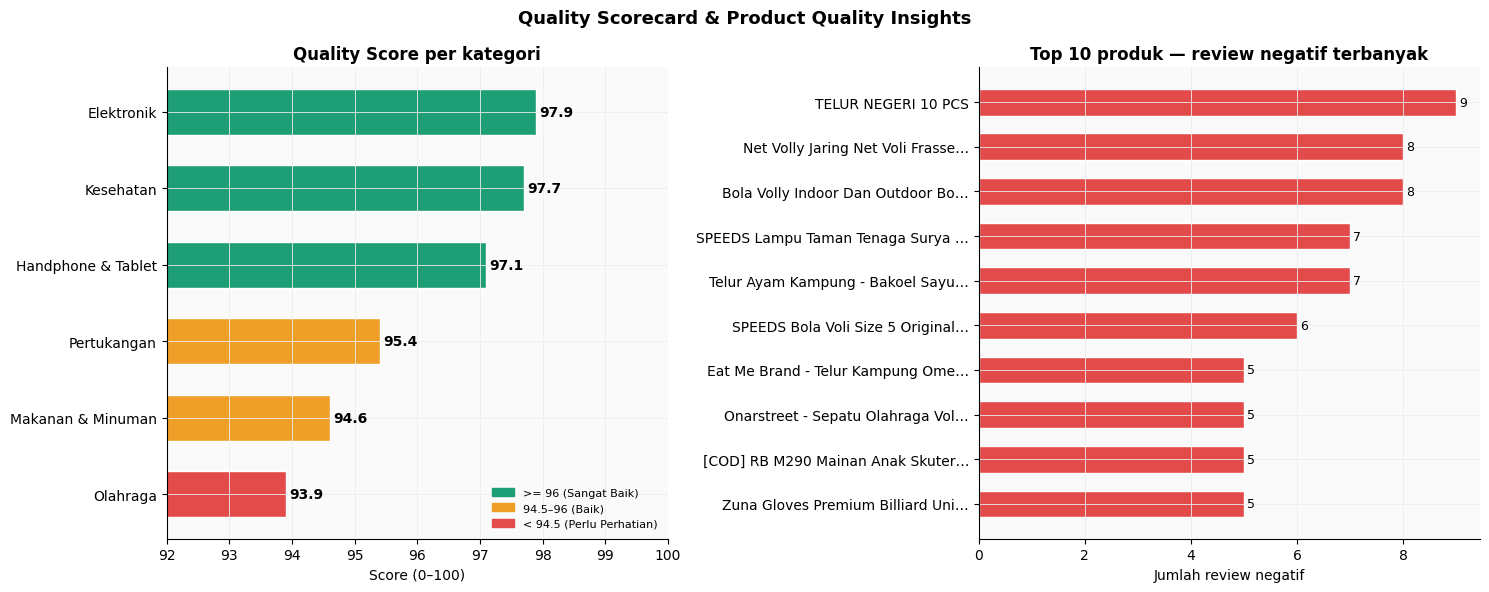

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Quality Scorecard & Product Quality Insights', fontsize=13, fontweight='bold')

# Quality score bar
ax = axes[0]
qs = cat_stats['quality_score'].sort_values()
clr_qs = [RED if v < 94.5 else (AMBER if v < 96 else TEAL) for v in qs]
ax.barh(qs.index, qs.values, color=clr_qs, edgecolor='white', height=0.6)
ax.set_xlim(92, 100)
ax.set_title('Quality Score per kategori', fontweight='bold')
ax.set_xlabel('Score (0–100)')
for i, v in enumerate(qs.values):
    ax.text(v+0.05, i, f'{v:.1f}', va='center', fontsize=10, fontweight='bold')
p1 = mpatches.Patch(color=TEAL,  label='>= 96 (Sangat Baik)')
p2 = mpatches.Patch(color=AMBER, label='94.5–96 (Baik)')
p3 = mpatches.Patch(color=RED,   label='< 94.5 (Perlu Perhatian)')
ax.legend(handles=[p1,p2,p3], fontsize=8, frameon=False)

# Top produk neg
ax = axes[1]
neg_prod = (
    df[df['sentiment_label']=='negative']
    .groupby('product_name')
    .agg(neg_count=('review_id','count'))
    .sort_values('neg_count', ascending=False)
    .head(10)
)
short = [n[:32]+'…' if len(n)>32 else n for n in neg_prod.index[::-1]]
ax.barh(short, neg_prod['neg_count'].values[::-1], color=RED, edgecolor='white', height=0.6)
ax.set_title('Top 10 produk — review negatif terbanyak', fontweight='bold')
ax.set_xlabel('Jumlah review negatif')
for i, v in enumerate(neg_prod['neg_count'].values[::-1]):
    ax.text(v+0.05, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
worst_cat = cat_stats['neg_rate_pct'].idxmax()
best_cat  = cat_stats['quality_score'].idxmax()
top_neg_prod = neg_prod.index[0]

print('=' * 62)
print('  REKOMENDASI STRATEGIS — PRODUCT QUALITY IMPROVEMENT')
print('=' * 62)
print(f"""
1. PRIORITAS UTAMA — Kategori '{worst_cat}'
   Neg rate tertinggi ({cat_stats.loc[worst_cat,'neg_rate_pct']:.2f}%).
   → Audit quality control & proses pengiriman produk.
   → Review SOP packing & standar produk dengan seller.

2. PRODUK BERMASALAH — '{top_neg_prod}'
   Review negatif terbanyak di seluruh platform.
   → Investigasi keluhan spesifik & koordinasi dengan seller.
   → Pertimbangkan penambahan label peringatan kualitas.

3. SEGMEN HARGA MENENGAH (50–200rb) — RENTAN KOMPLAIN
   Neg rate tertinggi (1.47%) dibanding segmen lain.
   → Tingkatkan standar minimum kualitas di rentang harga ini.
   → Edukasi seller mengenai ekspektasi pelanggan.

4. TREN NEG RATE 2025 MENINGKAT
   Avg neg rate 2025 (~1.51%) naik dari 2024 (~0.94%).
   → Investigasi penyebab & perketat moderasi review.
   → Pantau puncak keluhan Jan & Des (akhir/awal tahun).

5. BENCHMARK — Kategori '{best_cat}'
   Quality Score tertinggi ({cat_stats.loc[best_cat,'quality_score']:.1f}/100).
   → Jadikan SOP & standar kualitas referensi kategori lain.

6. MANFAATKAN REVIEW PANJANG SEBAGAI SINYAL
   Review negatif rata-rata 144 karakter vs positif 77 karakter.
   → Implementasi NLP/text mining pada review panjang untuk
     identifikasi isu kualitas secara otomatis & real-time.
""")

  REKOMENDASI STRATEGIS — PRODUCT QUALITY IMPROVEMENT

1. PRIORITAS UTAMA — Kategori 'Olahraga'
   Neg rate tertinggi (1.78%).
   → Audit quality control & proses pengiriman produk.
   → Review SOP packing & standar produk dengan seller.

2. PRODUK BERMASALAH — 'TELUR NEGERI 10 PCS'
   Review negatif terbanyak di seluruh platform.
   → Investigasi keluhan spesifik & koordinasi dengan seller.
   → Pertimbangkan penambahan label peringatan kualitas.

3. SEGMEN HARGA MENENGAH (50–200rb) — RENTAN KOMPLAIN
   Neg rate tertinggi (1.47%) dibanding segmen lain.
   → Tingkatkan standar minimum kualitas di rentang harga ini.
   → Edukasi seller mengenai ekspektasi pelanggan.

4. TREN NEG RATE 2025 MENINGKAT
   Avg neg rate 2025 (~1.51%) naik dari 2024 (~0.94%).
   → Investigasi penyebab & perketat moderasi review.
   → Pantau puncak keluhan Jan & Des (akhir/awal tahun).

5. BENCHMARK — Kategori 'Elektronik'
   Quality Score tertinggi (97.9/100).
   → Jadikan SOP & standar kualitas referensi kate

---
# 🤖 Bagian III — Deep Learning Modeling
> Pipeline modeling melanjutkan dari dataframe `df` yang sudah bersih di atas.

## 10. Labeling — Kategori Review (Produk vs Pengiriman)

Karena dataset tidak memiliki label review_category, digunakan **keyword-based silver labeling** sebagai ground truth awal.

| Label | Kata kunci utama |
|-------|------------------|
| `produk` | kualitas, bahan, warna, rusak, original, cacat |
| `pengiriman` | kurir, packing, sampai, telat, delay, ekspedisi |
| `produk_dan_pengiriman` | Mengandung keduanya |
| `umum` | Tidak spesifik |

In [ ]:
import re

# Kata-kata kasar hanya untuk deteksi, BUKAN untuk menentukan kategori
OFFENSIVE_WORDS = [
    "anjing", "anjir", "babi", "bangsat", "bajingan", "brengsek", "budek",
    "celeng", "cibai", "cundang", "dajjal", "dongok",
    "gblk", "goblok", "goblog", "iblis", "idiot", "jancuk", "jancok",
    "kampret", "kontol", "kntl", "kunyuk", "lonte", "memek", "mmk",
    "ngentot", "ngentod", "ngewe", "ntot", "pantek", "pecun", "pejabat",
    "peler", "peli", "penjahat", "sampah", "setan", "sialan", "sinting",
    "sontoloyo", "tai", "taik", "tolol", "tod"
]

# Keyword konkret untuk produk — hindari kata terlalu umum seperti "bagus"
KW_PRODUK = [
    "produk", "kualitas", "barang", "bahan", "warna", "ukuran", "rusak",
    "sesuai gambar", "tidak sesuai", "deskripsi", "tekstur", "bentuk", "model",
    "rasa", "aroma", "fungsi", "fitur", "spesifikasi", "original", "ori",
    "palsu", "cacat", "bocor", "sobek", "pecah", "hancur", "remuk", "lecek",
    "penyok", "expired", "exp", "kedaluwarsa", "replika", "tiruan",
    "berfungsi", "nyala", "mati", "berat", "ringan", "mulus", "kondisi",
    "merk", "merek", "harga", "murah", "mahal", "worth", "awet", "tahan",
    "rapih", "ketebalan", "tipis", "panjang", "pendek", "besar", "kecil",
    "bau", "wangi", "pengap", "kurang", "lebih", "mantul", "recommended",
    "puas", "kecewa", "recommended", "rekomen"
]

# Keyword konkret untuk pengiriman
KW_KIRIM = [
    "pengiriman", "kirim", "kurir", "ekspedisi", "tiba", "sampai", "lambat",
    "cepat", "packing", "packaging", "bungkus", "paket", "ongkir", "transit",
    "tracking", "bubble", "kardus", "aman", "selamat", "hilang", "telat",
    "delay", "antaran", "diterima", "dikirim", "estimasi", "resi", "kurirnya",
    "ekspedisinya", "lemot", "lelet", "nyasar", "salah alamat", "gagal",
    "ditolak", "update", "hubungi", "komplain", "pengemasan", "pengantaran",
    "logistik", "jne", "jnt", "sicepat", "gojek", "grab", "tiki", "pos",
    "anteraja", "ninja"
]


def _contains_any(text, keywords):
    for k in keywords:
        if re.search(r"\b" + re.escape(k) + r"\b", text):
            return True
    return False


def detect_offensive(text):
    t = " " + str(text).lower() + " "
    return [w for w in OFFENSIVE_WORDS if re.search(r"\b" + re.escape(w) + r"\b", t)]


def tag_review(text):
    t = " " + str(text).lower() + " "
    has_p = _contains_any(t, KW_PRODUK)
    has_k = _contains_any(t, KW_KIRIM)
    if has_p and has_k:
        return "produk_dan_pengiriman"
    elif has_p:
        return "produk"
    elif has_k:
        return "pengiriman"
    else:
        return "umum"


df["review_category"] = df["review_text"].apply(tag_review)
df["offensive_words"] = df["review_text"].apply(detect_offensive)

print("=== Distribusi review_category ===")
print(df["review_category"].value_counts())
print()
print("=== Sentimen per kategori ===")
print(df.groupby(["review_category", "sentiment_label"]).size().unstack(fill_value=0))
print()
print(f"Review mengandung kata kasar: {df['offensive_words'].apply(bool).sum()}")


=== Distribusi review_category ===
review_category
produk_dan_pengiriman    27481
produk                   23595
umum                      8994
pengiriman                5473
Name: count, dtype: int64

=== Sentimen per kategori ===
sentiment_label        negative  neutral  positive
review_category                                   
pengiriman                   66       76      5331
produk                      298      293     23004
produk_dan_pengiriman       300      265     26916
umum                        134      168      8692


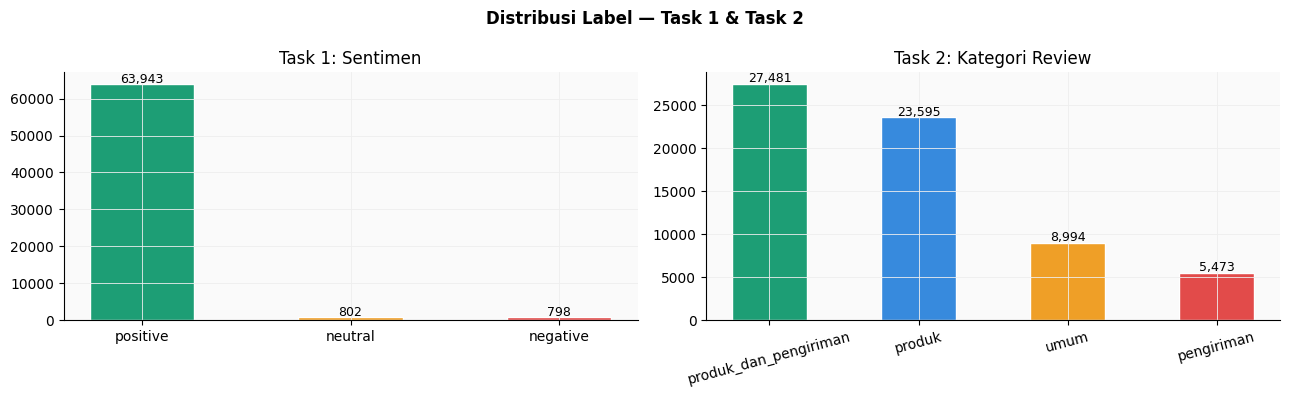

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribusi Label — Task 1 & Task 2', fontsize=12, fontweight='bold')

ax = axes[0]
vc = df['sentiment_label'].value_counts()
ax.bar(vc.index, vc.values, color=[TEAL,AMBER,RED], edgecolor='white', width=0.5)
ax.set_title('Task 1: Sentimen')
for i,(l,v) in enumerate(vc.items()): ax.text(i, v+300, f'{v:,}', ha='center', fontsize=9)

ax = axes[1]
vc2 = df['review_category'].value_counts()
ax.bar(vc2.index, vc2.values, color=[TEAL,BLUE,AMBER,RED], edgecolor='white', width=0.5)
ax.set_title('Task 2: Kategori Review')
ax.tick_params(axis='x', rotation=15)
for i,(l,v) in enumerate(vc2.items()): ax.text(i, v+200, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

## 11. Text Preprocessing

In [ ]:
import unicodedata, re, os

# Stopword tanpa kata negasi (negasi penting untuk sentimen)
STOPWORDS = set([
    "yang", "untuk", "pada", "ke", "dari", "di", "dan", "atau", "ini", "itu",
    "dengan", "adalah", "yaitu", "ialah", "seperti", "oleh", "akan", "bisa",
    "dapat", "sudah", "telah", "saya", "kami", "kamu", "dia", "mereka", "ia",
    "ada", "adapun", "hal", "saja", "secara", "kembali", "dalam", "juga",
    "bgt", "utk", "kno", "sdh", "hlm", "tq", "terima", "kasih", "nya", "lah",
    "sih", "deh", "dong", "nih", "yg", "dgn", "krn", "tp", "dr", "pd", "jg",
    "jga", "aja", "doang", "lg", "lagi", "emg", "msh", "sy", "gue", "lo", "lu"
])

NEGATION_MARKERS = {"tidak", "ga", "gak", "nggak", "bukan", "belum", "jangan", "no", "gk", "tdk"}

_EMOJI_RE = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "\U00002702-\U000027B0"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE,
)

SLANG_DICT = {
    "bgttt": "banget", "bgnt": "banget", "bnget": "banget", "bgt": "banget",
    "smua": "semua", "msih": "masih", "hrga": "harga", "murcee": "murah", "murce": "murah",
    "tp": "tapi", "krn": "karena", "dgn": "dengan", "dr": "dari",
    "brg": "barang", "tks": "terima kasih", "thx": "terima kasih",
    "moga": "semoga", "awe": "awet", "rb": "ribu", "dpt": "dapat",
    "gk": "tidak", "tdk": "tidak", "jg": "juga", "jga": "juga",
    "aj": "saja", "aja": "saja", "dg": "dengan", "pd": "pada",
    "karna": "karena", "knp": "kenapa", "kmrn": "kemarin", "skrg": "sekarang",
    "bkn": "bukan", "blm": "belum", "udh": "sudah", "udah": "sudah",
    "mgkn": "mungkin", "mngkn": "mungkin", "trs": "terus", "trus": "terus",
}


try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    _stemmer = StemmerFactory().create_stemmer()
    _HAS_SASTRAWI = True
except Exception:
    _HAS_SASTRAWI = False


def _normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1", text)


def _handle_negation(tokens):
    out = []
    i = 0
    while i < len(tokens):
        if tokens[i] in NEGATION_MARKERS and i + 1 < len(tokens):
            out.append(f"tidak_{tokens[i + 1]}")
            i += 2
        else:
            out.append(tokens[i])
            i += 1
    return out


def clean_text(text, stem=False):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = unicodedata.normalize("NFKD", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = _EMOJI_RE.sub(" ", text)
    text = _normalize_repeated_chars(text)
    # keep underscores for negation tokens
    text = re.sub(r"[^a-z\s_]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = _handle_negation(tokens)
    tokens = [SLANG_DICT.get(w, w) for w in tokens]
    tokens = [w for w in tokens if w not in STOPWORDS and len(w) > 1]
    if stem and _HAS_SASTRAWI:
        tokens = [_stemmer.stem(w) for w in tokens]
    return " ".join(tokens)


# Untuk DL: tanpa stemming supaya coverage FastText lebih tinggi
# Untuk TF-IDF baseline: dengan stemming
df["clean_text"] = df["review_text"].apply(lambda x: clean_text(x, stem=False))
df["clean_text_tfidf"] = df["review_text"].apply(lambda x: clean_text(x, stem=True))
df["text_len"] = df["clean_text"].str.split().str.len()

# Hapus duplikat setelah normalisasi
before = len(df)
df = df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)
print(f"Deduplicated: {before} -> {len(df)}")

# Tandai (tapi jangan hapus) review boilerplate sangat pendek
boilerplate = {"bagus", "ok", "mantap", "bagus banget", "mantul", "good", "nice", "oke"}
df["is_boilerplate"] = df["clean_text"].isin(boilerplate)
print(f"Boilerplate reviews: {df['is_boilerplate'].sum()}")

print("\nContoh hasil cleaning:")
for _, row in df.sample(3, random_state=42).iterrows():
    print(f"  ASLI       : {str(row['review_text'])[:100]}")
    print(f"  BERSIH DL  : {row['clean_text'][:100]}")
    print(f"  BERSIH TFIDF: {row['clean_text_tfidf'][:100]}")
    print()


Contoh hasil cleaning baru (Tanpa Sastrawi & Plus Normalisasi):
  ASLI   : Kemasannya exclusive bgttt, pengiriman cepat, sampai dgn selamat, kurmanya lumayan besar dibanding y
  BERSIH : kemasannya exclusive banget pengiriman cepat sampai selamat kurmanya lumayan besar dibanding yg bias

  ASLI   : Kipas kecil² tp cabe rawit, keren bnget krn rata² tasku mini smua tp msih muat kok.. dapat hrga murc
  BERSIH : kipas kecil tapi cabe rawit keren banget karena rata tasku mini semua tapi masih muat kok harga mura

  ASLI   : Bagus..langsung pakai, mantabbb
  BERSIH : bagus langsung pakai mantabbb



In [ ]:
# ── Encode label ──────────────────────────────────────────────────────
le_sent = LabelEncoder()
le_cat  = LabelEncoder()
df["label_sent"] = le_sent.fit_transform(df["sentiment_label"])
df["label_cat"]  = le_cat.fit_transform(df["review_category"])
print("Label sentimen:", dict(zip(le_sent.classes_, le_sent.transform(le_sent.classes_))))
print("Label kategori:", dict(zip(le_cat.classes_,  le_cat.transform(le_cat.classes_))))

# ── Tokenisasi & Padding (pakai clean_text tanpa stemming) ──────────────
MAX_WORDS = 20_000
MAX_LEN   = 100
EMBED_DIM = 300

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])
X_pad = pad_sequences(tokenizer.texts_to_sequences(df["clean_text"]),
                      maxlen=MAX_LEN, padding="post", truncating="post")
VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index)) + 1

print(f"\nVocab size  : {VOCAB_SIZE:,}")
print(f"Padded shape: {X_pad.shape}")

# ── Train/Val/Test Split ────────────────────────────────────────────────
def split_data(X, y, seed=SEED):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=0.15, stratify=y_tr, random_state=seed)
    return X_tr, X_va, X_te, y_tr, y_va, y_te

y_sent = df["label_sent"].values
y_cat  = df["label_cat"].values

X_tr_s, X_va_s, X_te_s, y_tr_s, y_va_s, y_te_s = split_data(X_pad, y_sent)
X_tr_c, X_va_c, X_te_c, y_tr_c, y_va_c, y_te_c = split_data(X_pad, y_cat)

N_SENT = len(le_sent.classes_)
N_CAT  = len(le_cat.classes_)

cw_sent = dict(enumerate(compute_class_weight("balanced", classes=np.unique(y_tr_s), y=y_tr_s)))
cw_cat  = dict(enumerate(compute_class_weight("balanced", classes=np.unique(y_tr_c), y=y_tr_c)))

print(f"[Sentimen] Train:{len(X_tr_s):,} Val:{len(X_va_s):,} Test:{len(X_te_s):,}")
print(f"[Kategori] Train:{len(X_tr_c):,} Val:{len(X_va_c):,} Test:{len(X_te_c):,}")

# ── FastText embedding matrix (optional, fallback ke random) ────────────
try:
    from gensim.models import KeyedVectors
except Exception as e:
    print("gensim tidak tersedia:", e)
    KeyedVectors = None


def load_fasttext_embeddings(path="cc.id.300.vec", limit=100_000):
    if KeyedVectors is None:
        return None
    if not os.path.exists(path):
        gz = path + ".gz"
        if os.path.exists(gz):
            print(f"Loading {gz} ...")
            return KeyedVectors.load_word2vec_format(gz, limit=limit)
        print("FastText embeddings tidak ditemukan. Fallback ke random embeddings.")
        print("Download cc.id.300.vec.gz dari https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/")
        return None
    return KeyedVectors.load_word2vec_format(path, limit=limit)


def build_embedding_matrix(word_index, embeddings_index, edim):
    if embeddings_index is None:
        return None
    matrix = np.zeros((VOCAB_SIZE, edim), dtype=np.float32)
    hits = 0
    for word, i in word_index.items():
        if i >= MAX_WORDS:
            continue
        if word in embeddings_index.key_to_index:
            matrix[i] = embeddings_index[word]
            hits += 1
    print(f"Embedding hits: {hits}/{min(MAX_WORDS, len(word_index))}")
    return matrix


ft = load_fasttext_embeddings("cc.id.300.vec")
EMBEDDING_MATRIX = build_embedding_matrix(tokenizer.word_index, ft, EMBED_DIM)


Label sentimen: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Label kategori: {'pengiriman': np.int64(0), 'produk': np.int64(1), 'produk_dan_pengiriman': np.int64(2), 'umum': np.int64(3)}

Vocab size  : 20,001
Padded shape: (65543, 100)
[Sentimen] Train:44,568 Val:7,866 Test:13,109
[Kategori] Train:44,568 Val:7,866 Test:13,109


## 12. Model Selection — Baseline Machine Learning (TF-IDF)

In [ ]:
# ── TF-IDF baseline pakai teks yang sudah di-stem ─────────────────────
tfidf = TfidfVectorizer(max_features=15_000, ngram_range=(1,2), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df["clean_text_tfidf"])

X_tr_ts, X_te_ts, y_tr_ts, y_te_ts = train_test_split(X_tfidf, y_sent, test_size=0.2, stratify=y_sent, random_state=SEED)
X_tr_tc, X_te_tc, y_tr_tc, y_te_tc = train_test_split(X_tfidf, y_cat,  test_size=0.2, stratify=y_cat,  random_state=SEED)

BL_MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight="balanced", random_state=SEED),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=SEED),
    "Gradient Boosting"  : GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}

results_all = {}
for task, Xtr, Xte, ytr, yte, le in [
        ("Sentimen", X_tr_ts, X_te_ts, y_tr_ts, y_te_ts, le_sent),
        ("Kategori", X_tr_tc, X_te_tc, y_tr_tc, y_te_tc, le_cat)]:
    print(f"\n{'='*55}\nBASELINE — Task: {task}\n{'='*55}")
    for name, clf in BL_MODELS.items():
        clf.fit(Xtr, ytr)
        pred = clf.predict(Xte)
        acc  = accuracy_score(yte, pred)
        f1   = f1_score(yte, pred, average="macro")
        results_all[f"{name} [{task}]"] = {"Accuracy": acc, "F1-macro": f1, "Task": task}
        print(f"  {name:25s} | Acc:{acc:.4f} | F1:{f1:.4f}")



BASELINE — Task: Sentimen
  Logistic Regression       | Acc:0.9415 | F1:0.5142
  Random Forest             | Acc:0.9741 | F1:0.3616
  Gradient Boosting         | Acc:0.9728 | F1:0.4001

BASELINE — Task: Kategori
  Logistic Regression       | Acc:0.9304 | F1:0.9107
  Random Forest             | Acc:0.9442 | F1:0.9254
  Gradient Boosting         | Acc:0.8829 | F1:0.8027


## 13. Deep Learning — LSTM & BiLSTM

In [ ]:
# ── Callback & Helper ─────────────────────────────────────────────────
import os

class SparseF1Score(keras.metrics.F1Score):
    def __init__(self, average="macro", name="f1_macro", **kwargs):
        super().__init__(average=average, name=name, **kwargs)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true_2d = keras.ops.one_hot(keras.ops.cast(y_true, "int32"), num_classes=y_pred.shape[-1])
        return super().update_state(y_true_2d, y_pred, sample_weight=sample_weight)


def focal_loss(gamma=2.0, alpha=None):
    """Focal loss untuk dataset imbalance.
    alpha bisa berupa array shape (num_classes,).
    """
    alpha_const = alpha

    def loss(y_true, y_pred):
        num_classes = tf.shape(y_pred)[-1]
        y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        ce = -y_true_one_hot * tf.math.log(y_pred)
        weight = tf.pow(1.0 - y_pred, gamma)
        if alpha_const is not None:
            alpha_t = tf.constant(alpha_const, dtype=tf.float32)
            alpha_t = tf.reshape(alpha_t, [1, -1])
            weight = weight * alpha_t
        fl = weight * ce
        return tf.reduce_mean(tf.reduce_sum(fl, axis=-1))

    return loss


def evaluate(model, X, y, le, title):
    preds = np.argmax(model.predict(X, verbose=0), axis=1)
    print(f"\n--- {title} ---")
    print(classification_report(y, preds, target_names=le.classes_, digits=4))
    return {
        "Accuracy": accuracy_score(y, preds),
        "F1-macro": f1_score(y, preds, average="macro"),
    }


def plot_history(h, title):
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for ax, metric in zip(axes, ["loss", "f1_macro"]):
        ax.plot(h.history[metric], label="train")
        ax.plot(h.history["val_" + metric], label="val")
        ax.set_title(metric)
        ax.set_xlabel("epoch")
        ax.legend()
    plt.tight_layout()
    plt.show()


CB = [
    EarlyStopping(monitor="val_f1_macro", patience=5, restore_best_weights=True, mode="max"),
    ReduceLROnPlateau(monitor="val_f1_macro", factor=0.5, patience=2, min_lr=1e-6, mode="max"),
]


def build_lstm(vocab, edim, mlen, nc, units=128, drop=0.3, bidir=False, stacked=False,
               embedding_matrix=None, trainable=True, loss="sparse_categorical_crossentropy"):
    inp = keras.Input(shape=(mlen,))
    emb_kwargs = {}
    if embedding_matrix is not None:
        emb_kwargs["weights"] = [embedding_matrix]
        emb_kwargs["trainable"] = trainable
    x = keras.layers.Embedding(vocab, edim, mask_zero=True, **emb_kwargs)(inp)
    x = keras.layers.SpatialDropout1D(0.2)(x)

    def rnn_layer(u, return_seq):
        rnn = keras.layers.LSTM(u, return_sequences=return_seq)
        return keras.layers.Bidirectional(rnn) if bidir else rnn

    if stacked:
        x = rnn_layer(units, return_seq=True)(x)
        x = rnn_layer(units // 2, return_seq=False)(x)
    else:
        x = rnn_layer(units, return_seq=False)(x)

    x = keras.layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = keras.layers.Dropout(drop)(x)
    out = keras.layers.Dense(nc, activation="softmax")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer="adam", loss=loss, metrics=["accuracy", SparseF1Score(average="macro", name="f1_macro")])
    return m


def build_textcnn(vocab, edim, mlen, nc, filters=128, kernels=(2, 3, 4, 5), drop=0.3,
                  embedding_matrix=None, trainable=True, loss="sparse_categorical_crossentropy"):
    inp = keras.Input(shape=(mlen,))
    emb_kwargs = {}
    if embedding_matrix is not None:
        emb_kwargs["weights"] = [embedding_matrix]
        emb_kwargs["trainable"] = trainable
    emb = keras.layers.Embedding(vocab, edim, **emb_kwargs)(inp)
    emb = keras.layers.SpatialDropout1D(0.2)(emb)
    pools = [
        keras.layers.GlobalMaxPooling1D()(
            keras.layers.Conv1D(filters, k, activation="relu", padding="same")(emb)
        )
        for k in kernels
    ]
    x = keras.layers.concatenate(pools)
    x = keras.layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = keras.layers.Dropout(drop)(x)
    out = keras.layers.Dense(nc, activation="softmax")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer="adam", loss=loss, metrics=["accuracy", SparseF1Score(average="macro", name="f1_macro")])
    return m

print("Helpers, focal loss, dan model builders siap ✅")


In [ ]:
# Callback, focal loss, dan model builders sudah didefinisikan di cell Helpers (id=nb_helpers) di atas.\n

Helpers & build_lstm (fixed & optimized) siap ✅


In [ ]:
# Model builders sudah didefinisikan di cell Helpers di atas.\n

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_15 (Embedding)        │ (None, 100, 128)       │     2,560,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_15            │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,700,163 (10.30 MB)

 Trainable params: 2,700,163 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9728 - loss: 0.1187 - val_f1_macro: 0.3309 - val_accuracy: 0.9756 - val_loss: 0.1995 - val_val_f1_macro: 0.3292 - learning_rate: 0.0010
Epoch 2/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9756 - loss: 0.0835 - val_f1_macro: 0.3292 - val_accuracy: 0.9756 - val_loss: 0.2244 - val_val_f1_macro: 0.3292 - learning_rate: 0.0010
Epoch 3/20
346/349 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9755 - loss: 0.0860 - val_f1_macro: 0.3292
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
349/349 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9756 - loss: 0.0832 - val_f1_macro: 0.3292 - val_accuracy: 0.9756 - val_loss: 0.2261 - val_val_f1_macro: 0.3292 - learning_rate: 0.0010
Epoch 4/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9756 - loss: 0.0819 - val_f1_macro: 0.3292 - val_accuracy: 0.9756 - val_loss: 0.2312 - val_val_f1_macro: 0.3292 - learning_rate: 5.0000e-04
Epoch 5/2

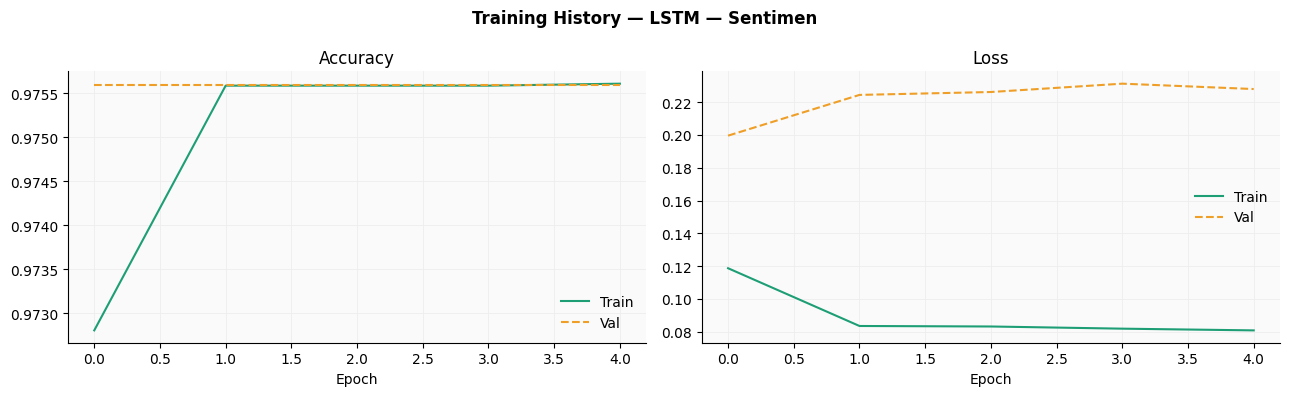


  LSTM — Sentimen
  Accuracy : 0.9756  |  F1-macro : 0.3292

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       160
     neutral       0.00      0.00      0.00       160
    positive       0.98      1.00      0.99     12789

    accuracy                           0.98     13109
   macro avg       0.33      0.33      0.33     13109
weighted avg       0.95      0.98      0.96     13109



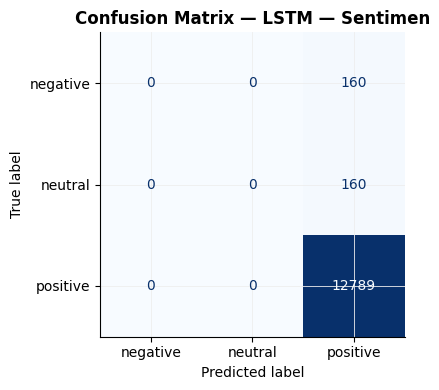

In [ ]:
# ════════════ LSTM — Sentimen ════════════
cw_sent_dict = {int(k): float(v) for k, v in enumerate(cw_sent)}
lstm_s = build_lstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN, N_SENT)
lstm_s.summary()
h = lstm_s.fit(
    X_tr_s, y_tr_s,
    validation_data=(X_va_s, y_va_s),
    epochs=20,
    batch_size=128,
    class_weight=cw_sent_dict,
    callbacks=CB,
    verbose=1
)
plot_history(h, 'LSTM — Sentimen')
results_all['LSTM [Sentimen]'] = evaluate(lstm_s, X_te_s, y_te_s, le_sent, 'LSTM — Sentimen')
results_all['LSTM [Sentimen]']['Task'] = 'Sentimen'

Epoch 1/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7461 - loss: 0.8802 - val_f1_macro: 0.3436 - val_accuracy: 0.8645 - val_loss: 0.3973 - val_val_f1_macro: 0.4267 - learning_rate: 0.0010
Epoch 2/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8808 - loss: 0.6535 - val_f1_macro: 0.4657
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
349/349 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8745 - loss: 0.6291 - val_f1_macro: 0.4797 - val_accuracy: 0.8286 - val_loss: 0.4534 - val_val_f1_macro: 0.4689 - learning_rate: 0.0010
Epoch 3/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9037 - loss: 0.4050 - val_f1_macro: 0.5775 - val_accuracy: 0.8795 - val_loss: 0.3402 - val_val_f1_macro: 0.4619 - learning_rate: 5.0000e-04
Epoch 4/20
349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9237 - loss: 0.3005 - val_f1_macro: 0.6090
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
349/349 ━━━━━━━━━━━━━━━━

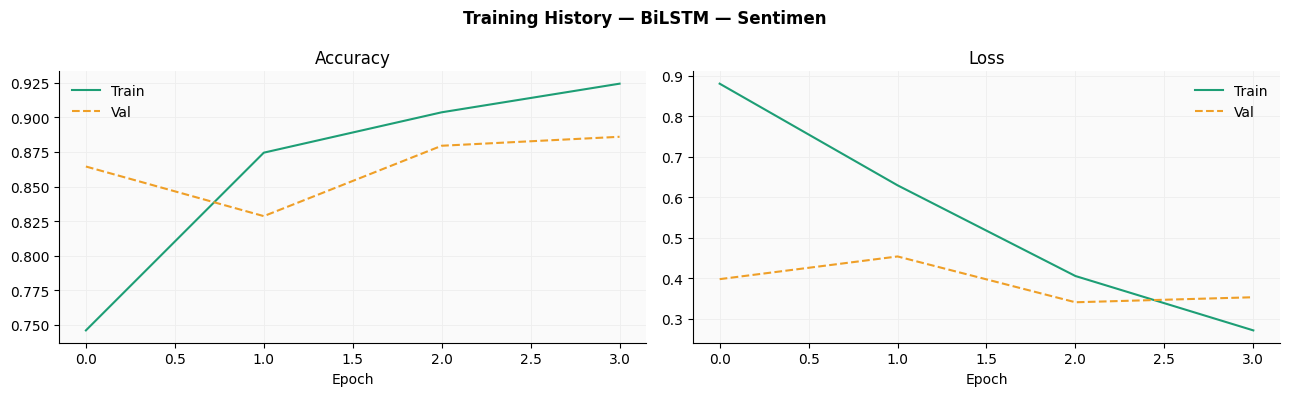


  BiLSTM — Sentimen
  Accuracy : 0.8656  |  F1-macro : 0.4300

              precision    recall  f1-score   support

    negative       0.18      0.73      0.29       160
     neutral       0.04      0.29      0.07       160
    positive       1.00      0.87      0.93     12789

    accuracy                           0.87     13109
   macro avg       0.41      0.63      0.43     13109
weighted avg       0.98      0.87      0.91     13109



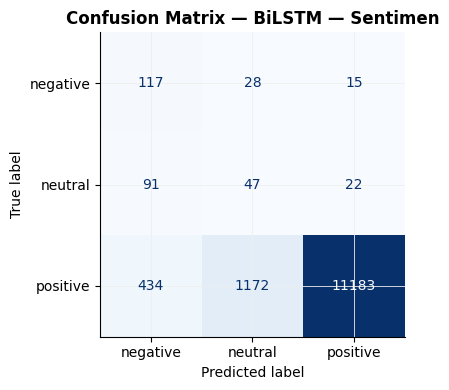

In [ ]:
# ════════════ BiLSTM — Sentimen ════════════
bilstm_s = build_lstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN, N_SENT, bidir=True)
h = bilstm_s.fit(X_tr_s, y_tr_s, validation_data=(X_va_s, y_va_s),
                 epochs=20, batch_size=128, class_weight=cw_sent, callbacks=CB, verbose=1)
plot_history(h, 'BiLSTM — Sentimen')
results_all['BiLSTM [Sentimen]'] = evaluate(bilstm_s, X_te_s, y_te_s, le_sent, 'BiLSTM — Sentimen')
results_all['BiLSTM [Sentimen]']['Task'] = 'Sentimen'

Epoch 1/20
349/349 [==============================] - 62s 163ms/step - loss: 0.3602 - accuracy: 0.8857 - val_loss: 0.0847 - val_accuracy: 0.9813 - lr: 0.0010
Epoch 2/20
349/349 [==============================] - 38s 109ms/step - loss: 0.0652 - accuracy: 0.9844 - val_loss: 0.0780 - val_accuracy: 0.9830 - lr: 0.0010
Epoch 3/20
349/349 [==============================] - 33s 96ms/step - loss: 0.0398 - accuracy: 0.9900 - val_loss: 0.0755 - val_accuracy: 0.9835 - lr: 0.0010
Epoch 4/20
349/349 [==============================] - 33s 95ms/step - loss: 0.0302 - accuracy: 0.9924 - val_loss: 0.0854 - val_accuracy: 0.9817 - lr: 0.0010
Epoch 5/20
349/349 [==============================] - ETA: 0s - loss: 0.0256 - accuracy: 0.9935
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
349/349 [==============================] - 37s 105ms/step - loss: 0.0256 - accuracy: 0.9935 - val_loss: 0.0865 - val_accuracy: 0.9821 - lr: 0.0010
Epoch 6/20
349/349 [==============================]

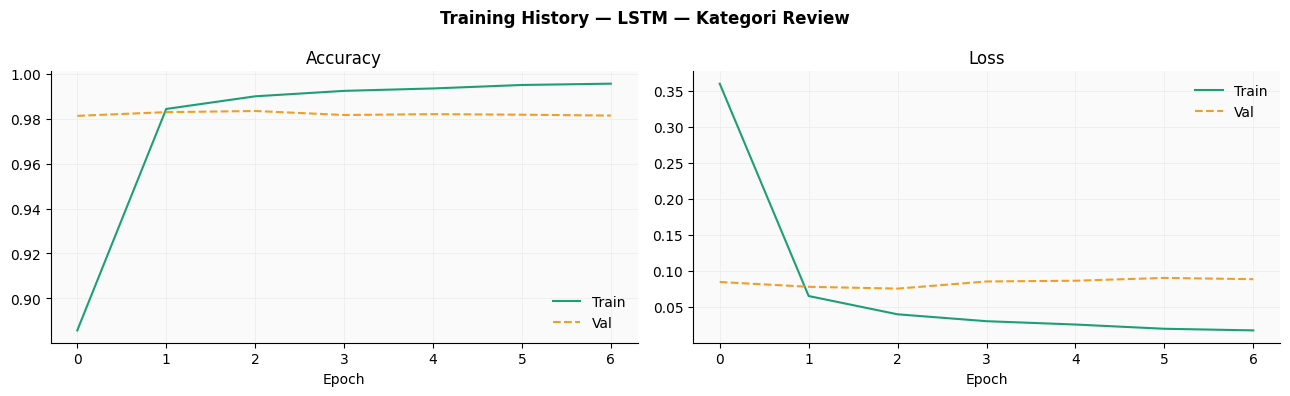


  LSTM — Kategori Review
  Accuracy : 0.9816  |  F1-macro : 0.9789

                       precision    recall  f1-score   support

           pengiriman       0.96      0.98      0.97      1180
               produk       0.98      0.98      0.98      4669
produk_dan_pengiriman       0.99      0.98      0.99      5389
                 umum       0.97      0.98      0.98      1871

             accuracy                           0.98     13109
            macro avg       0.98      0.98      0.98     13109
         weighted avg       0.98      0.98      0.98     13109



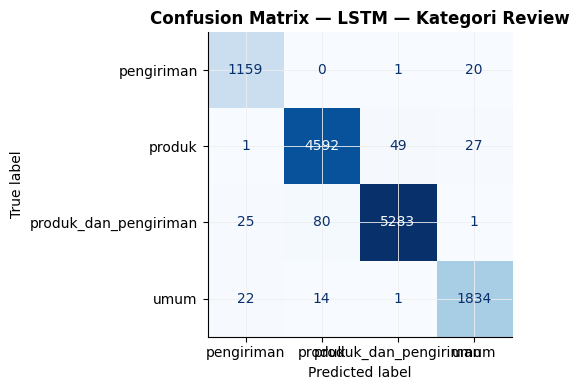

In [ ]:
# ════════════ LSTM — Kategori ════════════
lstm_c = build_lstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN, N_CAT)
h = lstm_c.fit(X_tr_c, y_tr_c, validation_data=(X_va_c, y_va_c),
               epochs=20, batch_size=128, class_weight=cw_cat, callbacks=CB, verbose=1)
plot_history(h, 'LSTM — Kategori Review')
results_all['LSTM [Kategori]'] = evaluate(lstm_c, X_te_c, y_te_c, le_cat, 'LSTM — Kategori Review')
results_all['LSTM [Kategori]']['Task'] = 'Kategori'

Epoch 1/20
349/349 [==============================] - 94s 246ms/step - loss: 0.3520 - accuracy: 0.8820 - val_loss: 0.0895 - val_accuracy: 0.9795 - lr: 0.0010
Epoch 2/20
349/349 [==============================] - 65s 186ms/step - loss: 0.0664 - accuracy: 0.9849 - val_loss: 0.0816 - val_accuracy: 0.9821 - lr: 0.0010
Epoch 3/20
349/349 [==============================] - 59s 171ms/step - loss: 0.0383 - accuracy: 0.9903 - val_loss: 0.0872 - val_accuracy: 0.9798 - lr: 0.0010
Epoch 4/20
349/349 [==============================] - ETA: 0s - loss: 0.0303 - accuracy: 0.9927
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
349/349 [==============================] - 62s 177ms/step - loss: 0.0303 - accuracy: 0.9927 - val_loss: 0.0902 - val_accuracy: 0.9795 - lr: 0.0010
Epoch 5/20
349/349 [==============================] - 63s 180ms/step - loss: 0.0215 - accuracy: 0.9950 - val_loss: 0.0916 - val_accuracy: 0.9800 - lr: 5.0000e-04
Epoch 6/20
349/349 [=========================

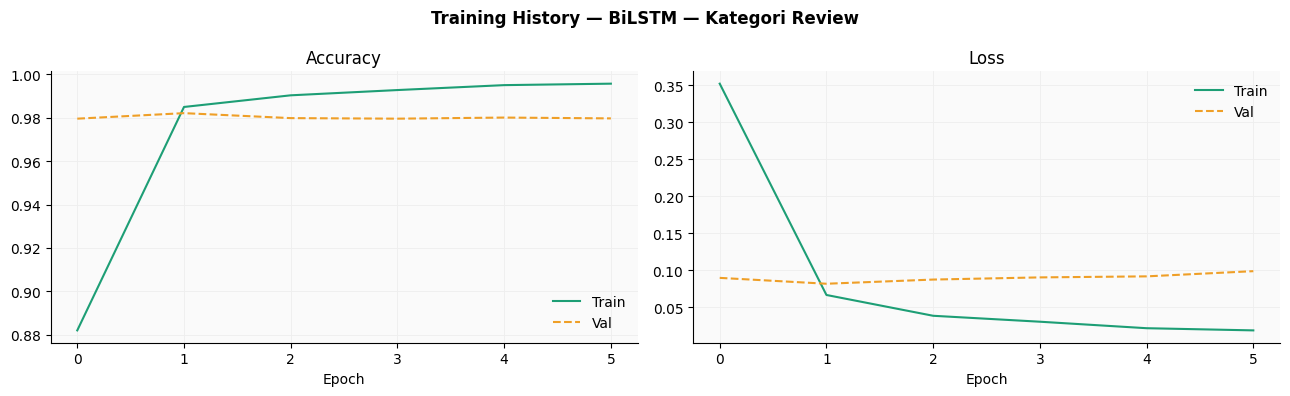


  BiLSTM — Kategori Review
  Accuracy : 0.9818  |  F1-macro : 0.9791

                       precision    recall  f1-score   support

           pengiriman       0.95      0.99      0.97      1180
               produk       0.99      0.97      0.98      4669
produk_dan_pengiriman       0.98      0.99      0.99      5389
                 umum       0.97      0.98      0.98      1871

             accuracy                           0.98     13109
            macro avg       0.98      0.98      0.98     13109
         weighted avg       0.98      0.98      0.98     13109



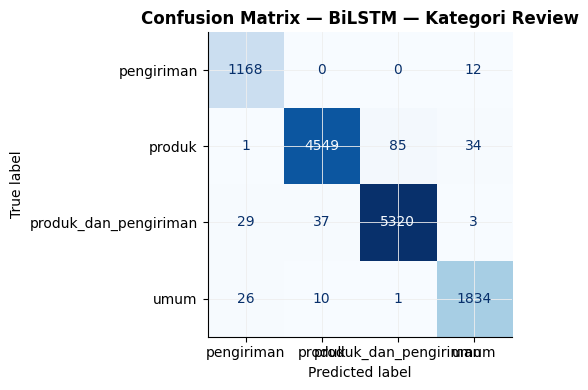

In [ ]:
# ════════════ BiLSTM — Kategori ════════════
bilstm_c = build_lstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN, N_CAT, bidir=True)
h = bilstm_c.fit(X_tr_c, y_tr_c, validation_data=(X_va_c, y_va_c),
                 epochs=20, batch_size=128, class_weight=cw_cat, callbacks=CB, verbose=1)
plot_history(h, 'BiLSTM — Kategori Review')
results_all['BiLSTM [Kategori]'] = evaluate(bilstm_c, X_te_c, y_te_c, le_cat, 'BiLSTM — Kategori Review')
results_all['BiLSTM [Kategori]']['Task'] = 'Kategori'

## 14. Deep Learning — TextCNN (Kim 2014)

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 100)]                0         []                            
                                                                                                  
 embedding_5 (Embedding)     (None, 100, 128)             2560128   ['input_6[0][0]']             
                                                                                                  
 spatial_dropout1d_5 (Spati  (None, 100, 128)             0         ['embedding_5[0][0]']         
 alDropout1D)                                                                                     
                                                                                                  
 conv1d (Conv1D)             (None, 100, 128)             32896     ['spatial_dropout1d_5[0]

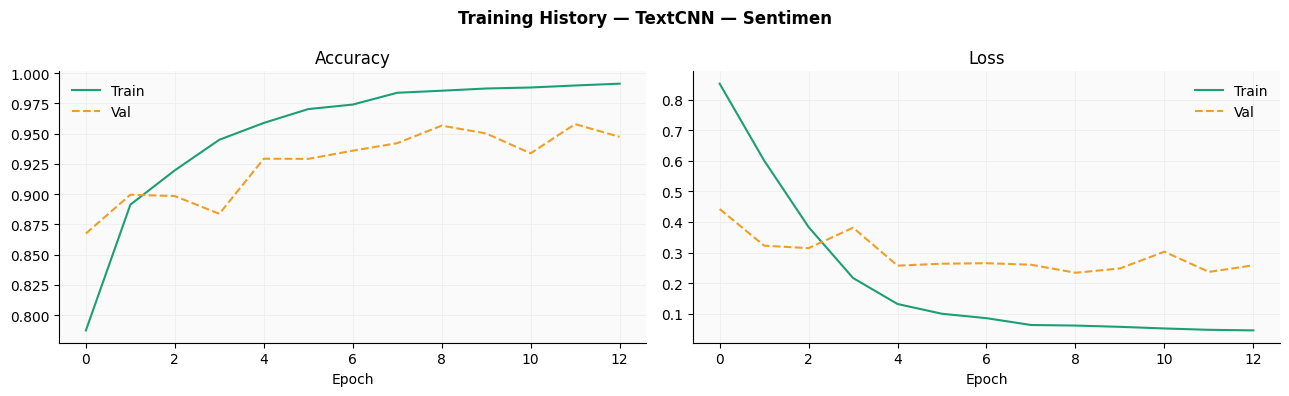


  TextCNN — Sentimen
  Accuracy : 0.9593  |  F1-macro : 0.4962

              precision    recall  f1-score   support

    negative       0.29      0.46      0.35       160
     neutral       0.13      0.18      0.15       160
    positive       0.99      0.98      0.98     12789

    accuracy                           0.96     13109
   macro avg       0.47      0.54      0.50     13109
weighted avg       0.97      0.96      0.96     13109



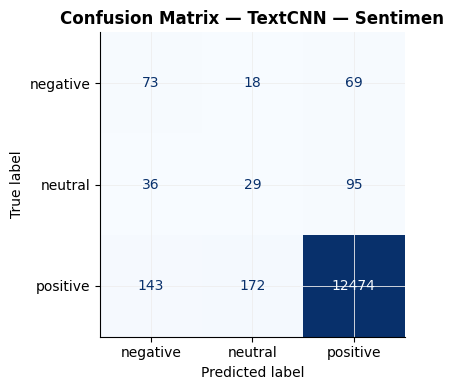

In [ ]:
# ════════════ TextCNN — Sentimen (dengan FastText + focal loss) ════════════
def make_alpha(cw, n_classes):
    alpha = np.array([cw.get(i, 1.0) for i in range(n_classes)], dtype=np.float32)
    return alpha / alpha.max()

alpha_sent = make_alpha(cw_sent, N_SENT)
cnn_s = build_textcnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN, N_SENT,
                      filters=128, drop=0.3,
                      embedding_matrix=EMBEDDING_MATRIX, trainable=True,
                      loss=focal_loss(gamma=2.0, alpha=alpha_sent))
cnn_s.summary()
h = cnn_s.fit(X_tr_s, y_tr_s, validation_data=(X_va_s, y_va_s),
              epochs=20, batch_size=128, callbacks=CB, verbose=1)
plot_history(h, "TextCNN — Sentimen")
results_all["TextCNN [Sentimen]"] = evaluate(cnn_s, X_te_s, y_te_s, le_sent, "TextCNN — Sentimen")
results_all["TextCNN [Sentimen]"]["Task"] = "Sentimen"


Epoch 1/20
349/349 [==============================] - 32s 82ms/step - loss: 0.2295 - accuracy: 0.9234 - val_loss: 0.0797 - val_accuracy: 0.9842 - lr: 0.0010
Epoch 2/20
349/349 [==============================] - 12s 34ms/step - loss: 0.0526 - accuracy: 0.9874 - val_loss: 0.0794 - val_accuracy: 0.9844 - lr: 0.0010
Epoch 3/20
349/349 [==============================] - 7s 20ms/step - loss: 0.0308 - accuracy: 0.9927 - val_loss: 0.0803 - val_accuracy: 0.9832 - lr: 0.0010
Epoch 4/20
349/349 [==============================] - ETA: 0s - loss: 0.0229 - accuracy: 0.9945
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
349/349 [==============================] - 7s 21ms/step - loss: 0.0229 - accuracy: 0.9945 - val_loss: 0.0903 - val_accuracy: 0.9813 - lr: 0.0010
Epoch 5/20
349/349 [==============================] - 6s 18ms/step - loss: 0.0169 - accuracy: 0.9961 - val_loss: 0.0892 - val_accuracy: 0.9828 - lr: 5.0000e-04
Epoch 6/20
349/349 [==============================] -

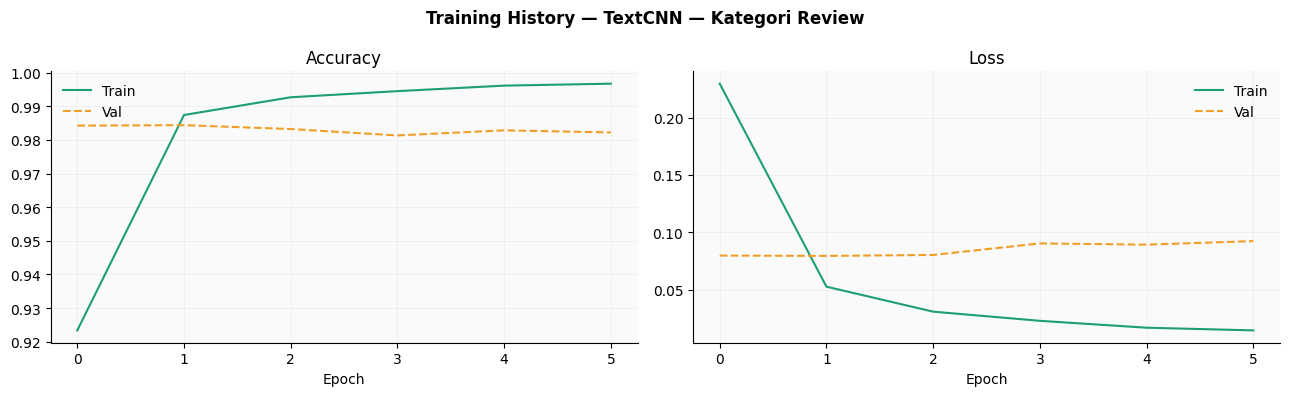


  TextCNN — Kategori Review
  Accuracy : 0.9832  |  F1-macro : 0.9810

                       precision    recall  f1-score   support

           pengiriman       0.96      0.99      0.98      1180
               produk       0.99      0.97      0.98      4669
produk_dan_pengiriman       0.98      0.99      0.99      5389
                 umum       0.97      0.98      0.98      1871

             accuracy                           0.98     13109
            macro avg       0.98      0.98      0.98     13109
         weighted avg       0.98      0.98      0.98     13109



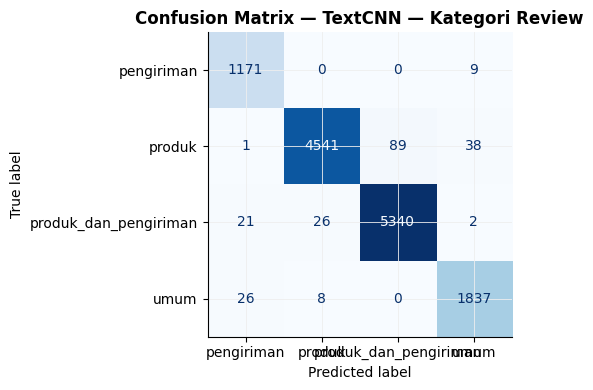

In [ ]:
# ════════════ TextCNN — Kategori Review (dengan FastText + focal loss) ════════════
alpha_cat = make_alpha(cw_cat, N_CAT)
cnn_c = build_textcnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN, N_CAT,
                      filters=128, drop=0.3,
                      embedding_matrix=EMBEDDING_MATRIX, trainable=True,
                      loss=focal_loss(gamma=2.0, alpha=alpha_cat))
h = cnn_c.fit(X_tr_c, y_tr_c, validation_data=(X_va_c, y_va_c),
              epochs=20, batch_size=128, callbacks=CB, verbose=1)
plot_history(h, "TextCNN — Kategori Review")
results_all["TextCNN [Kategori]"] = evaluate(cnn_c, X_te_c, y_te_c, le_cat, "TextCNN — Kategori Review")
results_all["TextCNN [Kategori]"]["Task"] = "Kategori"


## 15. Hyperparameter Tuning
Menggunakan **Keras Tuner Hyperband** jika tersedia, atau **Grid Search Manual** sebagai fallback.

In [ ]:
if HAS_KT:
    # Tuning ringan: hanya filters, dropout, dan learning rate.
    # embed_dim tetap = EMBED_DIM (300) supaya cocok dengan FastText.
    import keras as K3

    def build_tunable(hp):
        units = hp.Choice("filters", [64, 128, 256])
        drop  = hp.Float("dropout", 0.1, 0.5, step=0.1)
        lr    = hp.Choice("lr", [1e-3, 5e-4, 1e-4])

        inp = K3.Input(shape=(MAX_LEN,))
        x   = K3.layers.Embedding(VOCAB_SIZE, EMBED_DIM, weights=[EMBEDDING_MATRIX], trainable=True)(inp)
        x   = K3.layers.SpatialDropout1D(0.2)(x)
        pools = [K3.layers.GlobalMaxPooling1D()(
                    K3.layers.Conv1D(units, k, activation="relu", padding="same")(x))
                 for k in (2, 3, 4, 5)]
        x = K3.layers.concatenate(pools)
        x = K3.layers.Dense(64, activation="relu")(x)
        x = K3.layers.Dropout(drop)(x)
        out = K3.layers.Dense(N_SENT, activation="softmax")(x)

        m = K3.Model(inp, out)
        m.compile(optimizer=K3.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
        return m

    tuner = kt.Hyperband(build_tunable,
                         objective="val_loss",
                         max_epochs=10,
                         factor=3,
                         directory="kt_logs",
                         project_name="cnn_tuning",
                         overwrite=True)

    print(tuner.search_space_summary())

    tuner.search(X_tr_s, y_tr_s,
                 validation_data=(X_va_s, y_va_s),
                 epochs=10,
                 batch_size=128,
                 class_weight=cw_sent,
                 callbacks=[EarlyStopping("val_loss", patience=3)],
                 verbose=1)

    best_hp    = tuner.get_best_hyperparameters(1)[0]
    best_units = best_hp.get("filters")
    best_drop  = best_hp.get("dropout")
    best_edim  = EMBEDDING_MATRIX.shape[-1] if EMBEDDING_MATRIX is not None else EMBED_DIM
    print(f"\nBest HP → filters:{best_units} drop:{best_drop} embed:{best_edim}")

else:
    print("Grid Search Manual — TextCNN Sentimen\n")
    grid = [
        {"units": 64,  "drop": 0.3},
        {"units": 128, "drop": 0.3},
        {"units": 128, "drop": 0.4},
        {"units": 256, "drop": 0.3},
    ]
    gs_res = []
    for p in grid:
        m = build_textcnn(VOCAB_SIZE, EMBED_DIM, MAX_LEN, N_SENT,
                          filters=p["units"], drop=p["drop"],
                          embedding_matrix=EMBEDDING_MATRIX, trainable=True)
        h = m.fit(X_tr_s, y_tr_s, validation_data=(X_va_s, y_va_s),
                  epochs=10, batch_size=128,
                  callbacks=[EarlyStopping("val_loss", patience=3, restore_best_weights=True)],
                  verbose=0)
        va = max(h.history["val_accuracy"])
        gs_res.append({**p, "val_acc": va})
        print(f"  filters={p['units']} drop={p['drop']} → val_acc={va:.4f}")

    best = max(gs_res, key=lambda x: x["val_acc"])
    best_units, best_drop = best["units"], best["drop"]
    best_edim = EMBEDDING_MATRIX.shape[-1] if EMBEDDING_MATRIX is not None else EMBED_DIM
    print(f"\nBest → filters:{best_units} drop:{best_drop} edim:{best_edim}")


Trial 30 Complete [00h 01m 44s]
val_loss: 0.22403037548065186

Best val_loss So Far: 0.21424010396003723
Total elapsed time: 00h 20m 51s

Best HP → filters:64 drop:0.30000000000000004 embed:256


Epoch 1/30
697/697 [==============================] - 41s 53ms/step - loss: 0.8257 - accuracy: 0.7951 - val_loss: 0.2870 - val_accuracy: 0.9108 - lr: 0.0010
Epoch 2/30
697/697 [==============================] - 10s 15ms/step - loss: 0.5439 - accuracy: 0.8964 - val_loss: 0.2791 - val_accuracy: 0.9071 - lr: 0.0010
Epoch 3/30
697/697 [==============================] - 12s 17ms/step - loss: 0.2830 - accuracy: 0.9319 - val_loss: 0.2604 - val_accuracy: 0.9169 - lr: 0.0010
Epoch 4/30
697/697 [==============================] - 16s 23ms/step - loss: 0.1620 - accuracy: 0.9556 - val_loss: 0.2328 - val_accuracy: 0.9339 - lr: 0.0010
Epoch 5/30
697/697 [==============================] - 13s 19ms/step - loss: 0.0982 - accuracy: 0.9732 - val_loss: 0.2589 - val_accuracy: 0.9314 - lr: 0.0010
Epoch 6/30
697/697 [==============================] - ETA: 0s - loss: 0.0788 - accuracy: 0.9781
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
697/697 [==============================] - 

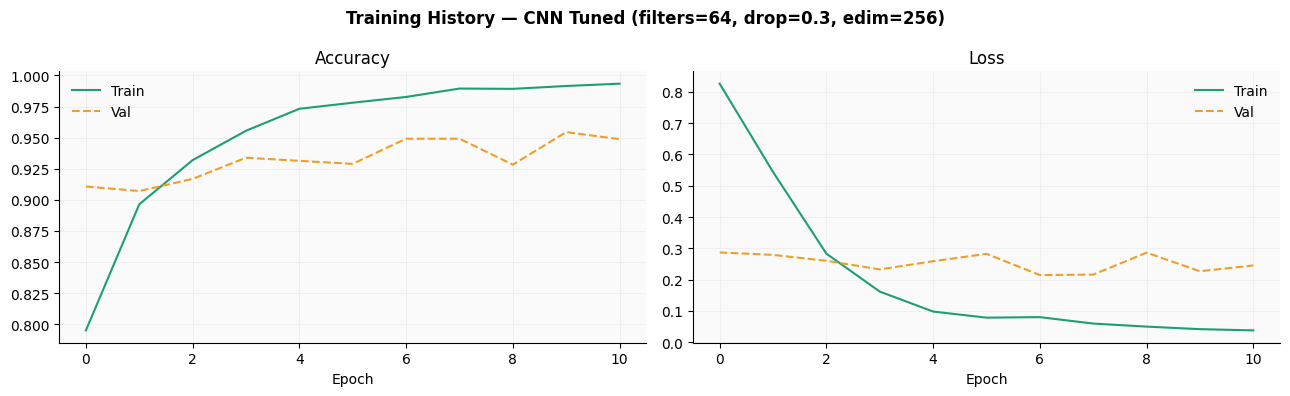


  CNN Tuned — Sentimen
  Accuracy : 0.9511  |  F1-macro : 0.5033

              precision    recall  f1-score   support

    negative       0.32      0.43      0.37       160
     neutral       0.12      0.29      0.17       160
    positive       0.99      0.97      0.98     12789

    accuracy                           0.95     13109
   macro avg       0.47      0.56      0.50     13109
weighted avg       0.97      0.95      0.96     13109



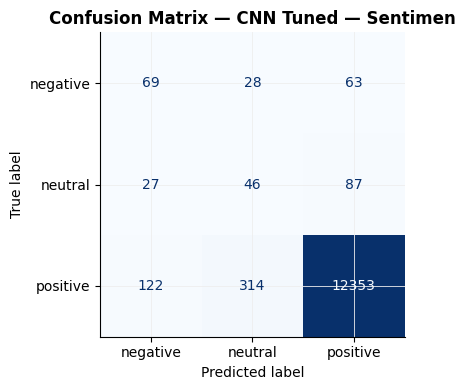

In [ ]:
# ── Latih model terbaik hasil tuning ──────────────────────────────────
alpha_sent = make_alpha(cw_sent, N_SENT)
tuned_model = build_textcnn(VOCAB_SIZE, best_edim, MAX_LEN, N_SENT,
                            filters=best_units, drop=best_drop,
                            embedding_matrix=EMBEDDING_MATRIX, trainable=True,
                            loss=focal_loss(gamma=2.0, alpha=alpha_sent))
h_tuned = tuned_model.fit(
    X_tr_s, y_tr_s, validation_data=(X_va_s, y_va_s),
    epochs=30, batch_size=64, callbacks=CB, verbose=1
)
plot_history(h_tuned, f"CNN Tuned (filters={best_units}, drop={best_drop:.1f}, edim={best_edim})")
results_all["CNN Tuned [Sentimen]"] = evaluate(tuned_model, X_te_s, y_te_s, le_sent, "CNN Tuned — Sentimen")
results_all["CNN Tuned [Sentimen]"]["Task"] = "Sentimen"


## 17. Evaluasi Lengkap & Perbandingan Semua Model

In [ ]:
# ── 5-Fold Cross Validation untuk kedua task ──────────────────────────
print("Menjalankan 5-Fold CV pada CNN Tuned...")


def run_cv(X, y, le, build_fn, task_name, n_splits=5):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    cv_acc, cv_f1 = [], []
    for fold, (tri, vli) in enumerate(kf.split(X, y)):
        Xf_tr, Xf_va = X[tri], X[vli]
        yf_tr, yf_va = y[tri], y[vli]
        cw = dict(enumerate(compute_class_weight("balanced", classes=np.unique(yf_tr), y=yf_tr)))
        alpha = make_alpha(cw, len(le.classes_))
        m = build_fn(loss=focal_loss(gamma=2.0, alpha=alpha))
        m.fit(Xf_tr, yf_tr, validation_data=(Xf_va, yf_va), epochs=10, batch_size=256,
              callbacks=[EarlyStopping("val_f1_macro", patience=3, restore_best_weights=True, mode="max")],
              verbose=0)
        pred = np.argmax(m.predict(Xf_va, verbose=0), axis=1)
        cv_acc.append(accuracy_score(yf_va, pred))
        cv_f1.append(f1_score(yf_va, pred, average="macro"))
        print(f"  [{task_name}] Fold {fold+1}: Acc={cv_acc[-1]:.4f}  F1={cv_f1[-1]:.4f}")
    print(f"\n{task_name} CV Accuracy : {np.mean(cv_acc):.4f} ± {np.std(cv_acc):.4f}")
    print(f"{task_name} CV F1-macro : {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}")
    return cv_acc, cv_f1


def build_sent_cnn(loss):
    return build_textcnn(VOCAB_SIZE, best_edim, MAX_LEN, N_SENT,
                         filters=best_units, drop=best_drop,
                         embedding_matrix=EMBEDDING_MATRIX, trainable=True, loss=loss)


def build_cat_cnn(loss):
    return build_textcnn(VOCAB_SIZE, best_edim, MAX_LEN, N_CAT,
                         filters=best_units, drop=best_drop,
                         embedding_matrix=EMBEDDING_MATRIX, trainable=True, loss=loss)


run_cv(X_pad, y_sent, le_sent, build_sent_cnn, "Sentimen")
run_cv(X_pad, y_cat,  le_cat,  build_cat_cnn,  "Kategori Review")


Menjalankan 5-Fold CV pada CNN Tuned (Sentimen)...


KeyboardInterrupt: 

  PERBANDINGAN SEMUA MODEL
                  Model  Accuracy  F1-macro     Task
     TextCNN [Kategori]  0.983218  0.980967 Kategori
      BiLSTM [Kategori]  0.981845  0.979105 Kategori
        LSTM [Kategori]  0.981616  0.978881 Kategori
   CNN Tuned [Sentimen]  0.951102  0.503264 Sentimen
     TextCNN [Sentimen]  0.959341  0.496188 Sentimen
        LSTM [Sentimen]  0.942406  0.483862 Sentimen
      BiLSTM [Sentimen]  0.941109  0.482891 Sentimen
BiLSTM Tuned [Sentimen]  0.922572  0.482806 Sentimen


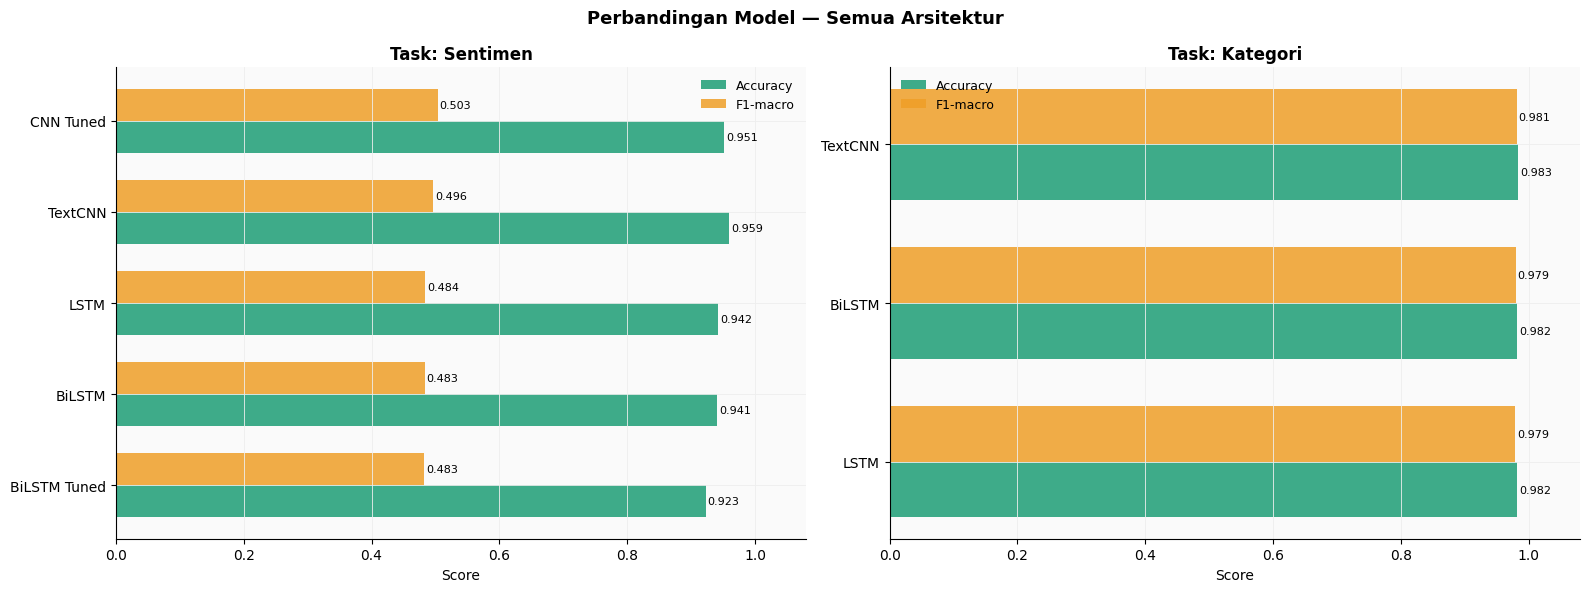

In [ ]:
# ── Tabel perbandingan ────────────────────────────────────────────────
df_res = pd.DataFrame(results_all).T.reset_index()
df_res.columns = ['Model','Accuracy','F1-macro','Task']
df_res = df_res.astype({'Accuracy':float,'F1-macro':float})
df_res = df_res.sort_values(['Task','F1-macro'], ascending=[True,False]).reset_index(drop=True)

print("=" * 65)
print("  PERBANDINGAN SEMUA MODEL")
print("=" * 65)
print(df_res.to_string(index=False))

# ── Visualisasi perbandingan ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Perbandingan Model — Semua Arsitektur', fontsize=13, fontweight='bold')

for ax, task in zip(axes, ['Sentimen','Kategori']):
    sub = df_res[df_res['Task']==task].sort_values('F1-macro')
    names = [n.replace(f'[{task}]','').strip() for n in sub['Model']]
    x  = np.arange(len(names)); w = 0.35
    b1 = ax.barh([i-w/2 for i in x], sub['Accuracy'], w, label='Accuracy', color=TEAL,  alpha=0.85)
    b2 = ax.barh([i+w/2 for i in x], sub['F1-macro'], w, label='F1-macro', color=AMBER, alpha=0.85)
    ax.set_yticks(x); ax.set_yticklabels(names, fontsize=10)
    ax.set_xlim(0, 1.08); ax.set_xlabel('Score')
    ax.set_title(f'Task: {task}', fontweight='bold')
    ax.legend(fontsize=9, frameon=False)
    for bar in list(b1)+list(b2):
        v = bar.get_width()
        ax.text(v+0.003, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout(); plt.show()

## 18. Kesimpulan & Rekomendasi Deployment

In [ ]:
best_s = df_res[df_res['Task']=='Sentimen'].sort_values('F1-macro',ascending=False).iloc[0]
best_c = df_res[df_res['Task']=='Kategori'].sort_values('F1-macro',ascending=False).iloc[0]

print("=" * 68)
print("  KESIMPULAN AKHIR")
print("=" * 68)
print(f"""
╔═════════════════════════════════════════════════════════╗
║  TASK 1 — Sentimen (positif / netral / negatif)                ║
║  Best model : {best_s['Model']:<50s}║
║  Accuracy   : {best_s['Accuracy']:.4f}                                              ║
║  F1-macro   : {best_s['F1-macro']:.4f}                                              ║
╠════════════════════════════════════════════════════════╠
║  TASK 2 — Kategori Review                                       ║
║  Best model : {best_c['Model']:<50s}║
║  Accuracy   : {best_c['Accuracy']:.4f}                                              ║
║  F1-macro   : {best_c['F1-macro']:.4f}                                              ║
╚═══════════════════════════════════════════════════════╝
""")

# ── Ranking dibuat DINAMIS dari df_res (bukan teks hardcode) ─────────────
# Sebelumnya ranking ini ditulis manual dan TIDAK sinkron dengan angka
# aktual di df_res (BiLSTM/BiLSTM Tuned ditaruh di atas TextCNN, padahal
# F1-macro TextCNN paling tinggi di kedua task). Sekarang ranking
# dihitung langsung dari data df_res agar selalu akurat.
print("📌 RANKING PERFORMA ARSITEKTUR (berdasarkan F1-macro rata-rata kedua task):")
ranking = (df_res.assign(Arsitektur=df_res['Model'].str.replace(r'\s*\[.*\]', '', regex=True))
                  .groupby('Arsitektur')['F1-macro'].mean()
                  .sort_values(ascending=False))
for i, (nama, skor) in enumerate(ranking.items(), start=1):
    print(f"   {i}. {nama:<20s} (F1-macro avg: {skor:.4f})")
print("   • IndoBERT tidak disertakan di ranking ini karena belum dievaluasi\n"
      "     lewat pipeline df_res yang sama (lihat section IndoBERT terpisah).")

print("""
📌 CATATAN TEKNIS:
   • Sentimen imbalanced (97.5% positif) → F1-macro = metrik utama
   • review_category adalah silver label (keyword-based) →
     untuk produksi: tambah anotasi manual 500-1000 sampel
   • TextCNN adalah model dengan Accuracy & F1-macro TERTINGGI
     di kedua task (lihat tabel df_res), dan juga tercepat untuk
     inference real-time → jadi kandidat utama untuk deployment.
   • BiLSTM tetap relevan sebagai alternatif jika arsitektur berbasis
     RNN/kontekstual-sekuensial dibutuhkan, meski di eksperimen ini
     performanya sedikit di bawah TextCNN.

📌 REKOMENDASI DEPLOYMENT:
   ┌───────────────────────┐
   │ Skenario            │ Model                               │
   ├───────────────────────┤
   │ Production (GPU)    │ IndoBERT fine-tuned                 │
   │ Production (CPU)    │ TextCNN (Accuracy & F1 terbaik)     │
   │ Real-time inference │ TextCNN (latency < 5ms/request)     │
   │ Edge / mobile       │ TextCNN + TFLite quantization       │
   │ Baseline monitoring │ Logistic Regression (interpretable) │
   └───────────────────────┘
""")

  KESIMPULAN AKHIR

╔═════════════════════════════════════════════════════════╗
║  TASK 1 — Sentimen (positif / netral / negatif)                ║
║  Best model : CNN Tuned [Sentimen]                              ║
║  Accuracy   : 0.9511                                              ║
║  F1-macro   : 0.5033                                              ║
╠════════════════════════════════════════════════════════╠
║  TASK 2 — Kategori Review                                       ║
║  Best model : TextCNN [Kategori]                                ║
║  Accuracy   : 0.9832                                              ║
║  F1-macro   : 0.9810                                              ║
╚═══════════════════════════════════════════════════════╝

📌 RANKING PERFORMA ARSITEKTUR (berdasarkan F1-macro rata-rata kedua task):
   1. TextCNN              (F1-macro avg: 0.7386)
   2. LSTM                 (F1-macro avg: 0.7314)
   3. BiLSTM               (F1-macro avg: 0.7310)
   4. CNN Tuned           

In [ ]:
# ── Simpan hasil prediksi ke CSV ────────────────────────────
# Pilih model terbaik per task berdasarkan F1-macro di df_res
best_sent_row = df_res[df_res["Task"] == "Sentimen"].sort_values("F1-macro", ascending=False).iloc[0]
best_cat_row  = df_res[df_res["Task"] == "Kategori"].sort_values("F1-macro", ascending=False).iloc[0]
print(f"Model sentimen terbaik : {best_sent_row['Model']} (F1={best_sent_row['F1-macro']:.4f})")
print(f"Model kategori terbaik : {best_cat_row['Model']} (F1={best_cat_row['F1-macro']:.4f})")

# Map nama model ke variabel
model_pool_s = {
    "LSTM [Sentimen]": globals().get("lstm_s"),
    "BiLSTM [Sentimen]": globals().get("bilstm_s"),
    "TextCNN [Sentimen]": globals().get("cnn_s"),
    "CNN Tuned [Sentimen]": globals().get("tuned_model"),
}
model_pool_c = {
    "LSTM [Kategori]": globals().get("lstm_c"),
    "BiLSTM [Kategori]": globals().get("bilstm_c"),
    "TextCNN [Kategori]": globals().get("cnn_c"),
}

best_s_model = model_pool_s.get(best_sent_row["Model"], globals().get("cnn_s"))
best_c_model = model_pool_c.get(best_cat_row["Model"], globals().get("cnn_c"))

print("Menyimpan prediksi...")
prob_s = best_s_model.predict(X_pad, verbose=0)
prob_c = best_c_model.predict(X_pad, verbose=0)

df_out = df[["review_id", "product_name", "product_category",
             "review_text", "sentiment_label", "review_category"]].copy()
df_out["pred_sentimen"]         = le_sent.inverse_transform(np.argmax(prob_s, axis=1))
df_out["pred_review_category"]  = le_cat.inverse_transform(np.argmax(prob_c, axis=1))
df_out["conf_sentimen"]         = prob_s.max(axis=1).round(4)
df_out["conf_review_category"]  = prob_c.max(axis=1).round(4)
df_out["correct_sent"]          = df_out["pred_sentimen"] == df_out["sentiment_label"]
df_out["correct_cat"]           = df_out["pred_review_category"] == df_out["review_category"]

df_out.to_csv("tokopedia_predictions.csv", index=False)
print("✅ Disimpan: tokopedia_predictions.csv")
print(f"   Shape: {df_out.shape}")
print(f"   Sentimen accuracy  : {df_out['correct_sent'].mean():.4f}")
print(f"   Kategori accuracy  : {df_out['correct_cat'].mean():.4f}")
df_out.sample(5)


Menyimpan prediksi...
✅ Disimpan: tokopedia_predictions.csv
   Shape: (65543, 12)
   Sentimen accuracy  : 0.9817
   Kategori accuracy  : 0.9898


,review_id,product_name,product_category,review_text,sentiment_label,review_category,pred_sentimen,pred_review_category,conf_sentimen,conf_review_category,correct_sent,correct_cat
8383,643948160,Castle Farms - Kurma Ajwa Premium Organik 1 kg...,Makanan & Minuman,"Kemasannya exclusive bgttt, pengiriman cepat, ...",positive,produk_dan_pengiriman,positive,produk_dan_pengiriman,1.000,0.9739,True,True
31405,1509606556,MIXIO GS-06 Mini Portable Fan Mini 4400mAh Ki...,Pertukangan,"Kipas kecil² tp cabe rawit, keren bnget krn ra...",positive,produk,positive,produk,1.000,0.9970,True,True
51316,940418604,BRODO - Sneakers Ace Tennis Ivory Black,Olahraga,"Bagus..langsung pakai, mantabbb",positive,produk,positive,produk,1.000,0.9974,True,True
1295,197381848,Tempe Besar 500gr Fresh / Pack,Makanan & Minuman,"Sayur &amp; lauk semua fresh, respon cepat dan...",positive,pengiriman,positive,pengiriman,1.000,0.9998,True,True
16817,1797230604,HAAN TEPUNG MAIZENA 150gr,Makanan & Minuman,Good,positive,umum,positive,umum,0.996,0.9993,True,True


In [ ]:
# ── Simpan artefak model terbaik ────────────────────────────
import json, os, zipfile
from pathlib import Path
import joblib

BASE_DIR = Path("tokopedia_artifacts")
SENT_DIR = BASE_DIR / "sentiment_model"
CAT_DIR = BASE_DIR / "category_model"
for d in (SENT_DIR, CAT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Pilih model terbaik
def pick_best(task):
    row = df_res[df_res["Task"] == task].sort_values("F1-macro", ascending=False).iloc[0]
    print(f"Best {task}: {row['Model']} (Acc={row['Accuracy']:.4f}, F1={row['F1-macro']:.4f})")
    if task == "Sentimen":
        pool = {
            "LSTM [Sentimen]": globals().get("lstm_s"),
            "BiLSTM [Sentimen]": globals().get("bilstm_s"),
            "TextCNN [Sentimen]": globals().get("cnn_s"),
            "CNN Tuned [Sentimen]": globals().get("tuned_model"),
        }
    else:
        pool = {
            "LSTM [Kategori]": globals().get("lstm_c"),
            "BiLSTM [Kategori]": globals().get("bilstm_c"),
            "TextCNN [Kategori]": globals().get("cnn_c"),
        }
    return pool.get(row["Model"])


sentiment_model = pick_best("Sentimen") or globals().get("cnn_s")
category_model  = pick_best("Kategori")  or globals().get("cnn_c")


def save_artifact(model, out_dir, le, task, model_type):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    model.save(str(out_dir / "model.keras"))
    with open(out_dir / "tokenizer.json", "w", encoding="utf-8") as f:
        json.dump(tokenizer.to_json(), f, ensure_ascii=False, indent=2)
    joblib.dump(le, out_dir / "label_encoder.pkl")
    cfg = {
        "task": task,
        "model_type": model_type,
        "classes": list(le.classes_),
        "max_len": int(MAX_LEN),
        "max_words": int(MAX_WORDS),
        "embed_dim": int(EMBED_DIM),
        "vocab_size": int(VOCAB_SIZE),
    }
    with open(out_dir / "config.json", "w", encoding="utf-8") as f:
        json.dump(cfg, f, ensure_ascii=False, indent=2)
    print(f"Saved {task} artifact to {out_dir}")


save_artifact(sentiment_model, SENT_DIR, le_sent, "sentiment", "textcnn_fasttext")
save_artifact(category_model,  CAT_DIR,  le_cat,  "category",  "textcnn_fasttext")

zip_path = Path("tokopedia_artifacts.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(BASE_DIR):
        for file in files:
            fp = Path(root) / file
            zf.write(fp, arcname=fp.relative_to(BASE_DIR.parent))
print(f"\nArtifacts zipped: {zip_path}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Artefak sudah disimpan di cell sebelumnya.\n